# Model-Agnostic Task Complexity Estimator
### Method 1: Structural Feature Score — No LLM Inference Required



The final complexity score formula is:

$$C(q) = w_S \cdot S + w_R \cdot R + w_T \cdot T + w_D \cdot D + w_{TT} \cdot TT \quad \in [0, 1]$$

| Layer | Symbol | Name | What it measures |
|-------|--------|------|------------------|
| L1 | **S** | Surface Features | How long and vocabulary-rich the query is |
| L2 | **R** | Reasoning Depth | How much cognitive thinking is needed |
| L3 | **T** | Tool Dependency | Whether external tools/APIs/code are needed |
| L4 | **D** | Domain Skills | How many knowledge domains are needed |
| L5 | **TT** | Task Type | What kind of output is expected |

**Key principle:** Zero LLM calls. Every feature comes from deterministic NLP rules.

---

## Why normalise all scores to [0, 1]?

Each feature (token count, depth, etc.) lives in a different numerical range:
- Token count might be 5 to 2000
- Bloom level is 1 to 6
- NER density is 0.0 to 1.0

We cannot add these directly — a token count of 100 does not mean the same as a Bloom score of 100. **Normalisation** maps every feature to the same [0, 1] scale so they can be fairly combined with weights.

The formula used is **min-max scaling**:
$$\text{scaled} = \frac{\text{value} - \text{min}}{\text{max} - \text{min}}$$

- If value equals min → result is 0.0 (least complex)
- If value equals max → result is 1.0 (most complex)
- Values outside the range are clipped to [0, 1]

## Install Dependencies

Run this cell **once**, then restart the kernel before running anything else.

**What each package does:**
- `spacy` — advanced NLP: breaks text into words, finds grammar structure, finds named entities (people, places, dates)
- `en_core_web_md` — a pre-trained English language model for spaCy (medium size, ~43MB). "md" means it includes word vectors (numerical representations of word meaning)
- `textstat` — computes text readability scores (not used heavily here, but available)
- `numpy` — fast math on arrays
- `pandas` — tables/dataframes for storing and analysing results
- `matplotlib` / `seaborn` — charts and plots
- `scipy` — statistical functions (Spearman correlation)
- `tqdm` — progress bars when processing thousands of queries

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Install Dependencies
# Run once, then restart the kernel.
# sys.executable ensures pip installs into the SAME Python this notebook uses,
# not some other Python installation on the system.
# check_call raises an error immediately if any install fails.
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

PACKAGES = ["spacy", "textstat", "scipy", "numpy", "pandas",
            "matplotlib", "seaborn", "tqdm"]

for pkg in PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# Download spaCy's medium English model.
# This model includes: tokenisation, POS tagging, dependency parsing,
# Named Entity Recognition (NER), and 300-dimensional word vectors.
subprocess.check_call(
    [sys.executable, "-m", "spacy", "download", "en_core_web_md", "--quiet"]
)

print("✅ All dependencies installed. Restart the kernel now, then run from Cell 1.")

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
/Users/poorna/Downloads/research/.venv/lib/python3.12/site-packages/debugpy/_vendored/force_pydevd.py:18: UserWarning: incompatible copy of pydevd already imported:
 /Users/poorna/Downloads/research/.venv/lib/python3.12/site-packages/pydevd_plugins/extensions/pydevd_plugin_omegaconf.py
  warnings.warn(msg + ':\n {}'.format('\n  '.join(_unvendored)))

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will

## Global Imports & spaCy Pipeline
Load ALL libraries here at the top so nothing is imported twice.
The spaCy model `_NLP` is loaded once and shared across all feature classes — parsing is expensive, so we never parse the same text twice.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Global Imports & spaCy Pipeline
# ─────────────────────────────────────────────────────────────────────────────
from __future__ import annotations  # write type hints like 'list[str]' in Python 3.9

import re           # regex — pattern matching in text
import math         # math.log() used for log-scale normalisation
import warnings     # suppresses noisy library warnings
from dataclasses import dataclass, field, asdict  # clean data containers
from typing import Dict, List, Optional, Tuple    # type hints for safer, clearer code
from pathlib import Path                           # cross-platform file paths

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import spacy
import textstat
from scipy.stats import spearmanr  # measures rank-order correlation
from tqdm import tqdm              # progress bars for slow loops

warnings.filterwarnings("ignore")

# ── Load spaCy model ONCE — all downstream classes reuse this singleton ───────
# The pipeline components loaded are:
#   tok2vec      → neural token embeddings (shared backbone)
#   tagger       → Part-of-Speech tags (noun, verb, adjective …)
#   parser       → dependency parse tree (how words relate to each other)
#   lemmatizer   → root form of words ("running" → "run")
#   ner          → Named Entity Recognition (finds people, places, dates, orgs)
_NLP = spacy.load("en_core_web_md")

print(f"✅ spaCy pipeline components: {_NLP.pipe_names}")
print(f"✅ Model: en_core_web_md  |  Vocab size: {len(_NLP.vocab):,} tokens")

✅ spaCy pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
✅ Model: en_core_web_md  |  Vocab size: 764 tokens


## Helper Utilities

Three small helper functions used everywhere in the notebook:

1. **`clip_to_range`** — ensures a value never goes below `lo` or above `hi`. We call this after every score calculation to guarantee all scores stay in [0, 1].

2. **`min_max_scale`** — the core normalisation function. Maps any value from its original range into [0, 1].

3. **`_tree_depth`** — walks a spaCy dependency parse tree recursively to find how deep the grammar nesting goes. Deep trees = complex sentence structures.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper Utilities
# ─────────────────────────────────────────────────────────────────────────────

def clip_to_range(value: float, lo: float = 0.0, hi: float = 1.0) -> float:
    """
    Clamp a value so it never falls outside [lo, hi].

    Why needed? After weighted combination of sub-scores, floating-point
    arithmetic can occasionally produce values like -0.0001 or 1.00003.
    This ensures all final scores are strictly within [0, 1].

    Example:
        clip_to_range(1.05)  → 1.0
        clip_to_range(-0.2)  → 0.0
        clip_to_range(0.73)  → 0.73
    """
    return max(lo, min(hi, value))


def min_max_scale(value: float, lo: float, hi: float) -> float:
    """
    Map a value from its original range [lo, hi] into [0, 1].

    Formula: (value - lo) / (hi - lo)

    Why? So we can fairly combine features measured in different units.
    For example:
        token_count=50,  range [8,167]  → (50-8)/(167-8) = 0.264
        bloom_level=3,   range [1,6]    → (3-1)/(6-1)    = 0.400
    Both are now comparable on the same [0,1] scale.

    Edge case: if lo == hi (all values are the same), return 0.0
    to avoid a division-by-zero error.
    """
    if hi == lo:
        return 0.0
    return clip_to_range((value - lo) / (hi - lo))


def _tree_depth(token: spacy.tokens.Token) -> int:
    """
    Recursively compute the depth of a token in the dependency parse tree.

    A dependency tree represents sentence grammar:
        Sentence: "The big dog quickly ran away"
        Tree:     ran (root)
                  ├── dog (subject)
                  │   ├── The (determiner)
                  │   └── big (adjective)
                  └── away (particle)
        Depth = 3 (root → dog → The or big)

    Deeper trees = more embedded clauses = more complex grammar.
    If a token has no children (it is a leaf node), its depth is 1.
    If it has children, its depth is 1 + the depth of its deepest child.
    """
    children = list(token.children)
    if not children:
        return 1  # leaf node: depth is 1
    return 1 + max(_tree_depth(child) for child in children)


def get_doc(text: str) -> spacy.tokens.Doc:
    """
    Parse text with the global spaCy model.
    Returns a Doc object containing tokens, POS tags, entities, and parse tree.
    """
    return _NLP(text)


print("✅ Helper functions defined.")

✅ Helper functions defined.


## Dataset Configuration

We configure paths to 5 benchmark datasets:

| Dataset | Domain | Why included |
|---------|--------|--------------|
| **GAIA** | General AI assistant tasks | Real-world multi-step tasks |
| **AIME** | Competition mathematics | Hard mathematical reasoning |
| **MMLU-Pro** | Multi-domain MCQ | Broad knowledge across subjects |
| **MuSiQue** | Multi-hop QA | Chained reasoning across facts |
| **SWE-bench** | Software engineering | Real code bug fixing |

These datasets span a wide range of known difficulty levels, which lets us later verify that our complexity scores match human-expected ordering.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset Configuration
# ─────────────────────────────────────────────────────────────────────────────

# Paths to pre-processed parquet files (adjust if your folder structure differs)
DATA_PATHS: Dict[str, Path] = {
    "gaia"      : Path("../datasets/processed/gaia.parquet"),
    "aime"      : Path("../datasets/processed/aime.parquet"),
    "mmlu_pro"  : Path("../datasets/processed/mmlu_pro.parquet"),
    "musique"   : Path("../datasets/processed/musique.parquet"),
    "swe_bench" : Path("../datasets/processed/swe_bench.parquet"),
}

# Where to save scored outputs
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # create folder if it doesn't exist

print("✅ Configuration set.")
print(f"   Output directory: {OUTPUT_DIR.resolve()}")
print("   Datasets configured:")
for name, path in DATA_PATHS.items():
    exists = "✓" if path.exists() else "✗ (not found)"
    print(f"     {name:<12} → {path}  {exists}")

✅ Configuration set.
   Output directory: /Users/poorna/Downloads/research/notebooks/data/processed
   Datasets configured:
     gaia         → ../datasets/processed/gaia.parquet  ✓
     aime         → ../datasets/processed/aime.parquet  ✓
     mmlu_pro     → ../datasets/processed/mmlu_pro.parquet  ✓
     musique      → ../datasets/processed/musique.parquet  ✓
     swe_bench    → ../datasets/processed/swe_bench.parquet  ✓


## Load Datasets

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Load Datasets
# ─────────────────────────────────────────────────────────────────────────────
datasets: Dict[str, pd.DataFrame] = {}

for name, path in DATA_PATHS.items():
    df = pd.read_parquet(path)
    datasets[name] = df
    print(f"\n{'─' * 60}")
    print(f"📂 Dataset : {name.upper()}")
    print(f"   Path    : {path}")
    print(f"   Shape   : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"   Columns : {list(df.columns)}")
    print(f"   Nulls   : {df.isnull().sum().sum():,} total missing values")

print(f"\n✅ Loaded {len(datasets)} datasets successfully")

# Save one example query for quick sanity checks in later cells
SAMPLE_QUERY: str = datasets["gaia"]["query"].iloc[0]
print(f"\nSample query (used in demos below):")
print(f"  '{SAMPLE_QUERY[:100]}...'")


────────────────────────────────────────────────────────────
📂 Dataset : GAIA
   Path    : ../datasets/processed/gaia.parquet
   Shape   : 165 rows × 7 cols
   Columns : ['id', 'query', 'answer', 'level', 'annotator_steps', 'annotator_tools', 'file_name']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : AIME
   Path    : ../datasets/processed/aime.parquet
   Shape   : 30 rows × 5 cols
   Columns : ['id', 'query', 'answer', 'year', 'solution']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : MMLU_PRO
   Path    : ../datasets/processed/mmlu_pro.parquet
   Shape   : 12,032 rows × 9 cols
   Columns : ['id', 'query', 'answer', 'answer_index', 'options', 'category', 'cot_content', 'src', 'cot_length']
   Nulls   : 0 total missing values

────────────────────────────────────────────────────────────
📂 Dataset : MUSIQUE
   Path    : ../datasets/processed/musique.parquet
   

## L1: Surface Features (S)

**What is L1 measuring?** The *surface* of the text — how long it is and how rich the vocabulary is, before looking at meaning or reasoning.

### The three sub-features:

**1. `token_count`** — the raw number of words (excluding punctuation and spaces).  
Why it matters: longer queries generally contain more sub-tasks and constraints.

**2. `ner_density`** — fraction of tokens that are *Named Entities* (people, organisations, places, dates, etc.).  
Formula: `entity_tokens / total_tokens`  
Why it matters: many named entities = the query is grounded in specific real-world knowledge, which is harder than abstract reasoning.

**3. `mattr`** — Moving-Average Type-Token Ratio (window = 25 tokens).  
Why it matters: a query using the same few words repeatedly is simpler than one with rich, varied vocabulary.  
Why *moving-average*? Plain TTR (unique words / total words) decreases as text gets longer even if the vocabulary is just as rich. MATTR fixes this by sliding a fixed 25-token window across the text and averaging the TTR at each position. This makes it *length-independent*.

### Normalisation bounds
The bounds (e.g., TC_LO=8, TC_HI=167) come from the **P5 and P95 percentiles** of our actual benchmark data. This means:
- The bottom 5% of queries get score 0
- The top 95% of queries get score 1
- Everything in between is linearly scaled

We avoid extremes (like P1/P99) to prevent outliers from compressing the rest of the scale.

### Sub-feature weights
- `token_count` gets weight **0.45** — length is the strongest surface signal
- `ner_density` gets weight **0.30** — entity density is a good proxy for knowledge specificity
- `mattr` gets weight **0.25** — vocabulary richness is useful but less dominant

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# L1: Surface Features (S)
# ─────────────────────────────────────────────────────────────────────────────

class SurfaceFeatures:
    """
    L1 — Surface Features.

    Extracts three length/richness signals from raw query text
    using only classical NLP — no LLM inference:
      - token_count : raw word count (excluding punctuation and spaces)
      - ner_density : fraction of tokens that are named entities
      - mattr       : Moving-Average Type-Token Ratio (window=25)

    Combined into a single score S ∈ [0, 1].
    """

    # ── Normalisation bounds (set from P5/P95 of benchmark data) ─────────────
    # These are updated automatically in Cell 6 based on actual data distribution.
    # Queries with token_count < 8 score 0.0 on this dimension.
    # Queries with token_count > 167 score 1.0 on this dimension.
    _TC_LO,    _TC_HI    = 8,    167     # token count range (P5=8, P95=167)
    _NER_LO,   _NER_HI   = 0.0,  0.29  # NER density range (P5=0.0, P95=0.29)
    _MATTR_LO, _MATTR_HI = 0.7265, 1.0   # MATTR range (P5=0.7265, P95=1.0)

    # ── Sub-feature weights (must sum to 1.0) ─────────────────────────────────
    _W_TC    = 0.45  # token count is the dominant surface signal
    _W_NER   = 0.30  # named entity density
    _W_MATTR = 0.25  # vocabulary diversity

    def __init__(self, text: str, doc: Optional[spacy.tokens.Doc] = None):
        self.text = text
        self.doc  = doc if doc is not None else get_doc(text)

  
    def _token_count(self) -> int:
        """Count meaningful tokens — skip punctuation (. , ! ?) and whitespace."""
        return sum(1 for t in self.doc if not t.is_punct and not t.is_space)

    def _ner_density(self) -> float:
        """
        Fraction of tokens belonging to a named entity span.

        Example: "Barack Obama visited Paris in 2023"
          Named entities: [Barack Obama] [Paris] [2023] → 4 entity tokens out of 6
          NER density = 4/6 = 0.667

        A high NER density means the query is about specific real-world things,
        making it harder to answer without factual knowledge.
        """
        total = max(len(self.doc), 1)  # avoid divide-by-zero on empty text
        entity_token_count = sum(len(ent) for ent in self.doc.ents)
        return round(entity_token_count / total, 4)

    def _mattr(self, window: int = 25) -> float:
        """
        Moving-Average Type-Token Ratio.

        How it works:
          1. Get all lowercase tokens (no punctuation/spaces)
          2. Slide a window of 25 tokens across the text
          3. At each window position, compute: unique_tokens / 25
          4. Average across all window positions

        Example with window=3:
          Tokens: ["the", "cat", "sat", "the", "cat"]
          Windows: ["the","cat","sat"] → 3/3=1.0
                   ["cat","sat","the"] → 3/3=1.0
                   ["sat","the","cat"] → 3/3=1.0
          MATTR = 1.0  (all windows are fully diverse)

        Short texts (< window size): falls back to plain TTR.
        """
        tokens = [t.lower_ for t in self.doc if not t.is_punct and not t.is_space]
        n = len(tokens)
        if n == 0:
            return 0.0
        if n <= window:  # too short for sliding window — use plain TTR
            return round(len(set(tokens)) / n, 4)
        ttr_scores = [
            len(set(tokens[i : i + window])) / window
            for i in range(n - window + 1)
        ]
        return round(sum(ttr_scores) / len(ttr_scores), 4)

    def raw_features(self) -> dict:
        """Return all sub-features in their original (unscaled) values."""
        return {
            "token_count" : self._token_count(),
            "ner_density" : self._ner_density(),
            "mattr"       : self._mattr(),
        }

    def score(self) -> Tuple[float, dict]:
        """
        Returns (S, raw_features) where S ∈ [0, 1].

        S = 0.45 * scaled_token_count
          + 0.30 * scaled_ner_density
          + 0.25 * scaled_mattr
        """
        raw = self.raw_features()

        s_tc    = min_max_scale(raw["token_count"], self._TC_LO,    self._TC_HI)
        s_ner   = min_max_scale(raw["ner_density"], self._NER_LO,   self._NER_HI)
        s_mattr = min_max_scale(raw["mattr"],       self._MATTR_LO, self._MATTR_HI)

        S = self._W_TC * s_tc + self._W_NER * s_ner + self._W_MATTR * s_mattr
        return clip_to_range(S), raw


# ── Quick demo ────────────────────────────────────────────────────────────────
_sf  = SurfaceFeatures(SAMPLE_QUERY)
_S, _raw_s = _sf.score()
print(f"Demo query : '{SAMPLE_QUERY[:80]}...'")
print(f"Raw values : {_raw_s}")
print(f"S score    : {_S:.4f}")

Demo query : 'A paper about AI regulation that was originally submitted to arXiv.org in June 2...'
Raw values : {'token_count': 55, 'ner_density': 0.1864, 'mattr': 0.9097}
S score    : 0.4933


## Calibrating Normalisation Bounds for L1

### Why do we calibrate bounds?

The normalisation bounds (min and max values) determine the scale. If we set `_TC_HI = 10000`, then a query with 167 tokens would score only 0.0167 — essentially 0 — which is wrong.

We use the **actual distribution of our data** to set sensible bounds:
- **P5/P95** (5th and 95th percentile): the most balanced approach — 90% of the data falls inside the [0,1] range, and extreme outliers are capped at 0 or 1.

### What is a saturation audit?

After setting bounds, we check if too many values are being *clipped* to 0 (floor saturation) or 1 (ceiling saturation).  
- **Floor saturation > 10%** → lower bound is too high, many queries score 0 even though they're not trivial
- **Ceiling saturation > 10%** → upper bound is too low, many queries score 1 even though they're not extreme

### Why use log scale for token_count?

Token counts are *right-skewed*: most queries are 10–100 tokens, but a few are 2000+ tokens. With linear scaling, these outliers compress all the other queries into a tiny range near 0.  

Log scaling fixes this:
- Linear: token=8 → 0.0, token=87 → 0.5, token=167 → 1.0
- Log:    token=8 → 0.0, token=37 → 0.5, token=167 → 1.0

The midpoint (0.5) shifts down so shorter queries get more room to differentiate.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Calibrating Normalisation Bounds for L1 (Surface Features)
# ─────────────────────────────────────────────────────────────────────────────

FEATURES   = ["token_count", "ner_density", "mattr"]
STRATEGIES = {"P2_P98": (2, 98), "P5_P95": (5, 95), "P10_P90": (10, 90)}

# Toggle options — flip these to experiment
USE_DATASET_BOUNDS = False  # True → use per-dataset bounds instead of global
USE_LOG_SCALE_TC   = True   # True → use log scale for token_count


# ── Log-scale normaliser for token_count ─────────────────────────────────────
def log_scale(value: float, lo: float, hi: float) -> float:
    """
    Compress wide token-count ranges using logarithm.

    Clips value to [lo, hi] first, then applies:
        (log(value) - log(lo)) / (log(hi) - log(lo))

    This makes short queries more distinguishable from each other,
    while still placing very long queries near 1.0.
    """
    value = max(lo, min(hi, value))
    return (math.log(value) - math.log(lo)) / (math.log(hi) - math.log(lo))


# ── Step 1: Extract raw features from every query in every dataset ────────────
def extract_surface_features(datasets: dict) -> pd.DataFrame:
    """Run SurfaceFeatures.raw_features() on every query and collect results."""
    rows = []
    for name, df in datasets.items():
        print(f"⚙  {name.upper()} — {len(df):,} queries")
        for _, row in tqdm(df.iterrows(), total=len(df), leave=False):
            sf  = SurfaceFeatures(str(row["query"]))
            raw = sf.raw_features()
            rows.append({"dataset": name, **raw})
    return pd.DataFrame(rows)


feature_df = extract_surface_features(datasets)
print(f"\n✅ {len(feature_df):,} total queries extracted\n")


# ── Step 2: Percentile report ─────────────────────────────────────────────────
# For each feature, we print mean, std, min/max, and key percentiles.
# Reading: if P95 of token_count = 167, that means 95% of queries have
# token_count ≤ 167. So 167 is a sensible upper bound.
def percentile_report(df: pd.DataFrame, label: str = "GLOBAL") -> pd.DataFrame:
    pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    rows = []
    for feat in FEATURES:
        s = df[feat]
        rows.append({
            "feature" : feat,
            "mean"    : s.mean().round(4),
            "std"     : s.std().round(4),
            "min"     : s.min().round(4),
            "max"     : s.max().round(4),
            **{f"p{p}": round(np.percentile(s, p), 4) for p in pcts},
        })
    report = pd.DataFrame(rows).set_index("feature")
    print(f"\n{'═'*60}\n  {label}\n{'═'*60}")
    print(report.to_string())
    return report


global_report = percentile_report(feature_df, "GLOBAL — all datasets pooled")
for name, group in feature_df.groupby("dataset"):
    percentile_report(group, f"{name.upper()} — {len(group):,} queries")


# ── Step 3: Recommended bounds ────────────────────────────────────────────────
def recommended_bounds(df: pd.DataFrame) -> pd.DataFrame:
    """Compute P2/P5/P10 and P90/P95/P98 as candidate normalisation bounds."""
    rows = []
    for feat in FEATURES:
        s   = df[feat]
        row = {"feature": feat}
        for label, (lo, hi) in STRATEGIES.items():
            row[f"{label}_LO"] = round(np.percentile(s, lo), 4)
            row[f"{label}_HI"] = round(np.percentile(s, hi), 4)
        rows.append(row)
    return pd.DataFrame(rows).set_index("feature")


global_bounds = recommended_bounds(feature_df)
print(f"\n{'═'*60}\n  RECOMMENDED BOUNDS — GLOBAL\n{'═'*60}")
print(global_bounds.to_string())

dataset_bounds: Dict[str, pd.DataFrame] = {}
for name, group in feature_df.groupby("dataset"):
    dataset_bounds[name] = recommended_bounds(group)
    print(f"\n{'═'*60}\n  RECOMMENDED BOUNDS — {name.upper()}\n{'═'*60}")
    print(dataset_bounds[name].to_string())


# ── Step 4: Saturation audit ──────────────────────────────────────────────────
# pct_floor: % of queries that score exactly 0.0 (below lower bound)
# pct_ceiling: % of queries that score exactly 1.0 (above upper bound)
# If either exceeds 10%, the bound needs adjusting.
def saturation_audit(df: pd.DataFrame) -> pd.DataFrame:
    current = {
        "token_count" : (SurfaceFeatures._TC_LO,    SurfaceFeatures._TC_HI),
        "ner_density" : (SurfaceFeatures._NER_LO,   SurfaceFeatures._NER_HI),
        "mattr"       : (SurfaceFeatures._MATTR_LO, SurfaceFeatures._MATTR_HI),
    }
    rows = []
    for feat, (lo, hi) in current.items():
        s = df[feat]
        rows.append({
            "feature"         : feat,
            "current_LO"      : lo,
            "current_HI"      : hi,
            "pct_floor (%)"   : round(100 * (s <= lo).mean(), 1),
            "pct_ceiling (%)" : round(100 * (s >= hi).mean(), 1),
        })
    audit = pd.DataFrame(rows).set_index("feature")
    print(f"\n{'═'*60}\n  SATURATION AUDIT  (>10% = adjust that bound)\n{'═'*60}")
    print(audit.to_string())
    return audit


audit = saturation_audit(feature_df)


# ── Step 5: Apply the chosen bounds to SurfaceFeatures class ──────────────────
ATTR_MAP = {
    "token_count" : ("_TC_LO",    "_TC_HI"),
    "ner_density" : ("_NER_LO",   "_NER_HI"),
    "mattr"       : ("_MATTR_LO", "_MATTR_HI"),
}


def _write_bounds(bounds: pd.DataFrame, strategy: str, label: str = "") -> None:
    """Write chosen percentile bounds into SurfaceFeatures class attributes."""
    for feat, (lo_attr, hi_attr) in ATTR_MAP.items():
        setattr(SurfaceFeatures, lo_attr, bounds.loc[feat, f"{strategy}_LO"])
        setattr(SurfaceFeatures, hi_attr, bounds.loc[feat, f"{strategy}_HI"])
    if label:
        print(f"  → {label}  "
              f"TC=[{SurfaceFeatures._TC_LO}, {SurfaceFeatures._TC_HI}]  "
              f"NER=[{SurfaceFeatures._NER_LO}, {SurfaceFeatures._NER_HI}]  "
              f"MATTR=[{SurfaceFeatures._MATTR_LO}, {SurfaceFeatures._MATTR_HI}]")


def apply_bounds(strategy: str = "P5_P95") -> None:
    """
    Applies the chosen percentile bounds and optionally patches score()
    to use log-scale for token_count.

    - strategy: which percentile pair to use (P2_P98, P5_P95, or P10_P90)
    - USE_DATASET_BOUNDS: store per-dataset bounds for dataset-specific scoring
    - USE_LOG_SCALE_TC: replace linear scaling with log scaling for token count
    """
    print(f"\nApplying {strategy} bounds "
          f"[dataset_bounds={USE_DATASET_BOUNDS}, log_scale_tc={USE_LOG_SCALE_TC}]")

    if USE_DATASET_BOUNDS:
        SurfaceFeatures._dataset_bounds = {
            ds: {
                feat: (
                    float(bdf.loc[feat, f"{strategy}_LO"]),
                    float(bdf.loc[feat, f"{strategy}_HI"]),
                )
                for feat in FEATURES
            }
            for ds, bdf in dataset_bounds.items()
        }
        print("  Per-dataset bounds stored in SurfaceFeatures._dataset_bounds")
        for ds, bmap in SurfaceFeatures._dataset_bounds.items():
            print(f"    {ds:12s} : {bmap}")
    else:
        _write_bounds(global_bounds, strategy, label="global")

    # Patch score() to use log_scale for token_count (if flag is on)
    def patched_score(self, dataset: str = None) -> Tuple[float, dict]:
        """
        Patched version of SurfaceFeatures.score().
        Respects USE_DATASET_BOUNDS and USE_LOG_SCALE_TC flags.

        Args:
            dataset: pass the dataset name when USE_DATASET_BOUNDS=True
                     so the right ruler is used for that dataset.
        """
        raw = self.raw_features()

        # Resolve which bounds to use
        if USE_DATASET_BOUNDS and dataset is not None:
            bmap = self._dataset_bounds.get(dataset)
            if bmap is None:
                raise ValueError(
                    f"Unknown dataset '{dataset}'. "
                    f"Available: {list(self._dataset_bounds.keys())}"
                )
            tc_lo,  tc_hi  = bmap["token_count"]
            ner_lo, ner_hi = bmap["ner_density"]
            ma_lo,  ma_hi  = bmap["mattr"]
        else:
            tc_lo,  tc_hi  = self._TC_LO,    self._TC_HI
            ner_lo, ner_hi = self._NER_LO,   self._NER_HI
            ma_lo,  ma_hi  = self._MATTR_LO, self._MATTR_HI

        # Scale each feature
        # token_count: use log scale if flag is on (better for skewed data)
        s_tc    = (log_scale if USE_LOG_SCALE_TC else min_max_scale)(
                      raw["token_count"], tc_lo, tc_hi)
        s_ner   = min_max_scale(raw["ner_density"], ner_lo, ner_hi)
        s_mattr = min_max_scale(raw["mattr"],       ma_lo,  ma_hi)

        S = self._W_TC * s_tc + self._W_NER * s_ner + self._W_MATTR * s_mattr
        return clip_to_range(S), raw

    SurfaceFeatures.score = patched_score
    print("✅ Bounds applied and score() patched successfully.\n")


apply_bounds("P5_P95")

# ── Verification ──────────────────────────────────────────────────────────────
print("Verification — scoring the same query with different options:")
_text = "Find and fix the authentication bug in the login service."
_sf   = SurfaceFeatures(_text)
_S, _raw = _sf.score()
print(f"  Global/log-scale → S={_S:.4f}  raw={_raw}")

if USE_DATASET_BOUNDS:
    _S2, _ = _sf.score(dataset="swe_bench")
    print(f"  SWE_BENCH ruler  → S={_S2:.4f}")

⚙  GAIA — 165 queries


⚙  AIME — 30 queries


⚙  MMLU_PRO — 12,032 queries


⚙  MUSIQUE — 2,417 queries


⚙  SWE_BENCH — 500 queries



✅ 15,144 total queries extracted


════════════════════════════════════════════════════════════
  GLOBAL — all datasets pooled
════════════════════════════════════════════════════════════
                mean      std     min        max    p1      p5      p10      p25      p50      p75       p90       p95    p99
feature                                                                                                                      
token_count  48.1797  71.9024  1.0000  2417.0000  5.00  8.0000  10.0000  15.0000  26.0000  52.0000  108.0000  167.0000  324.0
ner_density   0.1029   0.0963  0.0000     0.8333  0.00  0.0000   0.0000   0.0182   0.0858   0.1562    0.2308    0.2899    0.4
mattr         0.8724   0.0877  0.3338     1.0000  0.65  0.7265   0.7633   0.8162   0.8720   0.9333    1.0000    1.0000    1.0

════════════════════════════════════════════════════════════
  AIME — 30 queries
════════════════════════════════════════════════════════════
                mean      std      min

## L2: Reasoning Depth (R)

**What is L2 measuring?** How much *thinking* is required — not just what words are present, but what cognitive operations they demand.

### Sub-features:

**1. `bloom_level`** (weight 0.30) — Bloom's Taxonomy classifies cognitive tasks into 6 levels:  
  1. **Remember** — recall facts ("What year was Python released?")  
  2. **Understand** — explain/describe ("Describe how TCP/IP works")  
  3. **Apply** — use knowledge to solve ("Calculate the integral of x²")  
  4. **Analyze** — break apart and compare ("Analyze trade-offs between X and Y")  
  5. **Evaluate** — judge and critique ("Assess whether this algorithm is optimal")  
  6. **Create** — design or produce something new ("Design a caching system")  
  
  Detection: regex patterns match action verbs at each level. The *highest* matched level wins.

**2. `syntactic_depth`** (weight 0.20) — mean depth of the dependency parse tree over all sentences.  
  "Find x" → depth 2. "Find x such that if the value exceeds the threshold by more than delta..." → depth 10+.

**3. `multi_hop`** (weight 0.15) — binary (0 or 1). True if the query requires linking ≥2 distinct entity types AND uses relational words like "between", "versus", "relate", "compare".

**4. `negation_count`** (weight 0.10) — count of `neg` dependency arcs ("not", "never", "no"). Negations complicate reasoning.

**5. `conditional_count`** (weight 0.15) — count of conditional/causal conjunctions ("if", "unless", "because", "therefore"). These signal hypothetical reasoning.

**6. `modifier_density`** (weight 0.10) — ratio of adjectival (amod) and adverbial (advmod) modifiers to total tokens. More qualifiers = more constrained, nuanced task.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# L2: Reasoning Depth (R)
# ─────────────────────────────────────────────────────────────────────────────

# ── Bloom's Taxonomy verb lexicon (levels 1–6) ────────────────────────────────
# Each level has a list of action verbs/phrases that signal that cognitive tier.
# Longer phrases are matched FIRST to avoid partial matches
# (e.g., "compare and contrast" should not match as just "compare" at level 2).
_BLOOM_VERBS: Dict[int, List[str]] = {
    1: [  # Remember — surface recall, no transformation needed
        "define","list","recall","name","identify","recognize","state","label",
        "match","select","locate","arrange","duplicate","memorize","repeat",
        "reproduce","copy","quote","order","record","relate","underline",
        "who is","when was","where is","what year","what is the capital",
    ],
    2: [  # Understand — interpretation, paraphrase, summarise
        "explain","describe","interpret","paraphrase","restate","translate",
        "clarify","elaborate","simplify","convert","classify","categorize",
        "sort","group","infer","predict","conclude from","anticipate",
        "extrapolate","summarize","abstract","generalize","outline",
        "illustrate","give an example","represent","compare","report",
        "review","discuss","indicate","rewrite","what is the difference",
    ],
    3: [  # Apply — procedural, computational tasks, use knowledge
        "apply","use","implement","execute","carry out","perform","administer",
        "operate","employ","utilize","solve","compute","calculate","estimate",
        "determine","find","derive the value","work out","demonstrate",
        "show how to","illustrate how","construct","build","produce","make",
        "prepare","complete","modify","develop a solution","simulate","run",
        "test","sketch","map","write a function","code","script",
    ],
    4: [  # Analyze — decompose, compare, trace relationships
        "analyze","analyse","differentiate","distinguish","discriminate",
        "separate","decompose","deconstruct","break down","parse","dissect",
        "organize","structure","integrate","diagram","correlate",
        "attribute","deduce","detect","examine","investigate",
        "compare and contrast","contrast","examine differences",
        "compare the trade-offs","trade-off","trade-offs",
        "what are the trade-offs","explain why","what causes","trace",
        "map the relationship","identify assumptions","identify biases",
        "debate","prioritize",
    ],
    5: [  # Evaluate — judge, critique, recommend, defend
        "evaluate","assess","judge","critique","criticize","review critically",
        "appraise","rate","rank","check","monitor","validate","verify","debug",
        "judge whether","measure","inspect","score","justify","defend",
        "argue for","argue against","support","refute","counter","recommend",
        "decide","choose between","determine the best","conclude",
        "is it better to","should we","which is more","what is the optimal",
    ],
    6: [  # Create — synthesize, design, prove from scratch
        "design","plan","devise","propose","formulate","architect","blueprint",
        "create","develop","generate","produce","invent","originate","pioneer",
        "compose","author","draft","synthesize","combine","assemble","compile",
        "derive","prove","demonstrate that","show that","formally show",
        "from first principles","from scratch","hypothesize","theorize",
        "conjecture","postulate","novel","new approach","new method",
        "original","come up with","propose a new","imagine a new",
    ],
}

# Pre-compile patterns: longest phrases first to prevent partial matches
_BLOOM_PATTERNS: Dict[int, re.Pattern] = {
    lvl: re.compile(
        r"\b(?:" + "|".join(
            re.escape(v) for v in sorted(verbs, key=len, reverse=True)
        ) + r")\b",
        re.IGNORECASE,
    )
    for lvl, verbs in _BLOOM_VERBS.items()
}

# Conditional/causal conjunctions that signal hypothetical reasoning
_CONDITIONAL_TOKENS = frozenset([
    "if","unless","provided","assuming","given","suppose","suppose that",
    "in the event","whenever","only if","even if","as long as",
    "because","since","therefore","thus","hence","consequently",
    "as a result","due to","owing to","so that","in order to",
])


class ReasoningDepth:
    """
    L2 — Reasoning Depth.

    Measures cognitive and structural complexity via:
      - Bloom's taxonomy level   (1–6)    : what cognitive operation is demanded
      - Syntactic tree depth              : how deep the grammar nesting is
      - Multi-hop indicator      (0 or 1) : does the query chain across entities
      - Negation count                    : logical inversions ("not", "never")
      - Conditional count                 : hypothetical/causal constructs
      - Modifier density                  : adjectival + adverbial qualifiers

    Combined into R ∈ [0, 1].
    """

    # Sub-feature weights (sum = 1.0)
    _W = {
        "bloom":     0.30,  # cognitive level is the strongest reasoning signal
        "syn_depth": 0.20,  # syntactic embedding
        "multi_hop": 0.15,  # entity chaining
        "negation":  0.10,  # logical inversions
        "condition": 0.15,  # hypothetical/causal reasoning
        "modifier":  0.10,  # qualifier density
    }

    def __init__(self, text: str, doc: Optional[spacy.tokens.Doc] = None):
        self.text = text
        self.doc  = doc if doc is not None else get_doc(text)

    def _bloom_level(self) -> int:
        """
        Return the HIGHEST Bloom level matched in the text (1–6).
        Default is 1 if no verb matches any level.
        We check from level 6 down to 1 and stop at the first match.
        """
        for lvl in range(6, 0, -1):
            if _BLOOM_PATTERNS[lvl].search(self.text):
                return lvl
        return 1  # default: Remember level

    def _syntactic_depth(self) -> float:
        """
        Mean maximum dependency-tree depth over all sentences.
        Each sentence's tree depth is measured from its root verb
        down to its deepest dependent word.
        Higher value = more deeply embedded clause structure.
        """
        depths = [_tree_depth(sent.root) for sent in self.doc.sents]
        return round(float(np.mean(depths)) if depths else 0.0, 4)

    def _is_multi_hop(self) -> bool:
        """
        Heuristic: query is multi-hop if it has ≥2 distinct entity TYPES
        AND at least one relational/comparison word.

        Example: "Compare the GDP of France and Germany" → True
          - Entity types: {GPE (France), GPE (Germany)}
          - Relational token: "compare" ✓

        Note: we check entity *types* (like ORG, GPE, DATE), not entity
        *names*, to avoid requiring identical entity types.
        """
        entity_types = {ent.label_ for ent in self.doc.ents}
        if len(entity_types) < 2:
            return False
        relational_tokens = {"and","between","both","versus","vs","compared",
                             "relate","link","connect","differ","same","than"}
        query_tokens = {t.lower_ for t in self.doc}
        return bool(query_tokens & relational_tokens)

    def _negation_count(self) -> int:
        """Count tokens labelled with 'neg' dependency arc (not, never, no)."""
        return sum(1 for t in self.doc if t.dep_ == "neg")

    def _conditional_count(self) -> int:
        """Count how many conditional/causal conjunctions appear in the query."""
        tokens_lower = {t.lower_ for t in self.doc}
        return len(tokens_lower & _CONDITIONAL_TOKENS)

    def _modifier_density(self) -> float:
        """
        Ratio of (adjective + adverb modifiers) to total tokens.
        amod = adjectival modifier ("large" in "large model")
        advmod = adverbial modifier ("quickly" in "runs quickly")
        Denser modifiers → more constrained/nuanced query.
        """
        total = max(len(self.doc), 1)
        mods  = sum(1 for t in self.doc if t.dep_ in {"amod", "advmod"})
        return round(mods / total, 4)

    def raw_features(self) -> dict:
        return {
            "bloom_level"       : self._bloom_level(),
            "syntactic_depth"   : self._syntactic_depth(),
            "multi_hop"         : int(self._is_multi_hop()),
            "negation_count"    : self._negation_count(),
            "conditional_count" : self._conditional_count(),
            "modifier_density"  : self._modifier_density(),
        }

    def score(self) -> Tuple[float, dict]:
        """
        Returns (R, raw_features).  R ∈ [0, 1].

        Normalisation ranges used:
          bloom_level:     1–6  → divide by 5 to get [0,1]
          syntactic_depth: 1–15 → typical range in NLP benchmarks
          negation_count:  0–4  → 4+ negations is already very unusual
          conditional_count: 0–5
          modifier_density: 0–0.5 (50% modifiers is extremely dense)
        """
        raw = self.raw_features()

        # Bloom: levels 1–6, subtract 1 and divide by 5 to get [0,1]
        s_bloom = (raw["bloom_level"] - 1) / 5.0
        s_depth = min_max_scale(raw["syntactic_depth"],  1.0, 15.0)
        s_hop   = float(raw["multi_hop"])   # already 0 or 1
        s_neg   = min_max_scale(raw["negation_count"],   0,   4)
        s_cond  = min_max_scale(raw["conditional_count"],0,   5)
        s_mod   = min_max_scale(raw["modifier_density"], 0.0, 0.5)

        W = self._W
        R = (W["bloom"]     * s_bloom +
             W["syn_depth"] * s_depth +
             W["multi_hop"] * s_hop   +
             W["negation"]  * s_neg   +
             W["condition"] * s_cond  +
             W["modifier"]  * s_mod)
        return clip_to_range(R), raw


# ── Demo ────────────────────────────────────────────────────────────────────
_rd     = ReasoningDepth(SAMPLE_QUERY)
_R, _rr = _rd.score()
print(f"Demo : '{SAMPLE_QUERY[:70]}...'")
print(f"Raw  : {_rr}")
print(f"R    : {_R:.4f}")

Demo : 'A paper about AI regulation that was originally submitted to arXiv.org...'
Raw  : {'bloom_level': 2, 'syntactic_depth': 8.0, 'multi_hop': 1, 'negation_count': 0, 'conditional_count': 0, 'modifier_density': 0.0339}
R    : 0.3168


## Tool Dependency (T)

**What is L3 measuring?** Whether the task requires calling *external tools* — code execution, web search, databases, APIs, etc. This is a proxy for *agentic complexity*.

**Method:** Regex scan over a curated keyword lexicon grouped into 8 tool categories:

| Category | Example signals |
|----------|-----------------|
| `code_execution` | run, execute, script, debug, bash, jupyter |
| `web_search` | search, browse, latest, real-time, fetch, url |
| `file_io` | read file, csv, pdf, download, upload, export |
| `api_call` | api, rest, endpoint, oauth, http, webhook |
| `database` | sql, query, select, mongodb, postgres, redis |
| `external_service` | slack, github, email, jira, openai |
| `math_computation` | integral, eigenvalue, probability, regression |
| `multimodal` | image, transcribe, ocr, video, audio |

**Scoring:**  
T = number of distinct categories triggered / 4 (saturation at 4+ categories → T = 1.0)

**Why saturation at 4?** Triggering 4+ separate tool categories is already an extremely complex agentic task. Beyond that, additional categories don't meaningfully increase difficulty further.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  L3: Tool Dependency (T)
# ─────────────────────────────────────────────────────────────────────────────

_TOOL_SIGNALS: Dict[str, List[str]] = {
    "code_execution": [
        "run","execute","compile","script","program","code","function",
        "algorithm","implement","debug","unit test","pytest","bash","terminal",
        "command line","cli","shell","subprocess","notebook","jupyter",
    ],
    "web_search": [
        "search","browse","look up","find online","google","bing","retrieve",
        "latest","current","real-time","live","up-to-date","news",
        "fetch","scrape","crawl","url","website","webpage",".com",".org",".in",
    ],
    "file_io": [
        "read file","write file","open file","save to","load from","csv","json",
        "excel","pdf","word doc","docx","txt","download","upload","import",
        "export","parse document","extract from","dataset",
    ],
    "api_call": [
        "api","rest","graphql","endpoint","request","response","http","https",
        "curl","webhook","oauth","token","authenticate","authorize",
        "call service","microservice","grpc",
    ],
    "database": [
        "database","sql","query","select","insert","update","delete","join",
        "table","schema","mongodb","postgres","mysql","sqlite","redis",
        "elasticsearch","nosql",
    ],
    "external_service": [
        "slack","email","calendar","send message","notify","alert",
        "github","jira","trello","confluence","zapier","ifttt",
        "gpt","llm","openai","anthropic","claude","gemini",
    ],
    "math_computation": [
        "calculate","compute","integral","derivative","matrix","solve equation",
        "eigenvalue","optimize","gradient","probability","statistics",
        "regression","fourier","laplace",
    ],
    "multimodal": [
        "image","photo","picture","diagram","chart","graph","plot","video",
        "audio","speech","transcribe","ocr","caption","visualize",
    ],
}

# Compile each category into one regex — longest terms first to avoid partial matches
_TOOL_PATTERNS: Dict[str, re.Pattern] = {
    cat: re.compile(
        r"\b(?:" + "|".join(re.escape(t) for t in sorted(terms, key=len, reverse=True)) + r")\b",
        re.IGNORECASE,
    )
    for cat, terms in _TOOL_SIGNALS.items()
}


class ToolDependency:
    """
    L3 — Tool Dependency.

    Identifies which external tool categories the task likely requires
    and returns T ∈ [0, 1].

    T = min(category_count / 4, 1.0)

    1 category triggered → T = 0.25  (moderate tool use)
    2 categories         → T = 0.50
    3 categories         → T = 0.75
    4+ categories        → T = 1.0  (complex agentic task)
    """

    _MAX_CATS = 4  # saturation point

    def __init__(self, text: str):
        self.text = text

    def raw_features(self) -> dict:
        hits = {cat: bool(_TOOL_PATTERNS[cat].search(self.text))
                for cat in _TOOL_PATTERNS}
        return {
            "matched_categories": [c for c, v in hits.items() if v],
            "category_count":     sum(hits.values()),
            "category_flags":     hits,
        }

    def score(self) -> Tuple[float, dict]:
        """Returns (T, raw_features).  T ∈ [0, 1]."""
        raw = self.raw_features()
        T   = clip_to_range(raw["category_count"] / self._MAX_CATS)
        return T, raw


# ── Demo ────────────────────────────────────────────────────────────────────
for _q in [
    "Write a Python script to scrape the latest stock prices from a financial API.",
    "What year was Python released?",
    SAMPLE_QUERY[:80] + "...",
]:
    _td = ToolDependency(_q)
    _T, _rt = _td.score()
    print(f"T={_T:.2f}  tools={_rt['matched_categories']}")
    print(f"  Query: '{_q[:70]}'\n")

T=0.75  tools=['code_execution', 'web_search', 'api_call']
  Query: 'Write a Python script to scrape the latest stock prices from a financi'

T=0.00  tools=[]
  Query: 'What year was Python released?'

T=0.25  tools=['web_search']
  Query: 'A paper about AI regulation that was originally submitted to arXiv.org'



## Cell 9 — L4: Domain Skills (D)

**What is L4 measuring?** How many distinct *knowledge domains* are needed, and whether the task involves *temporal reasoning* (dates, timelines, past/future).

### Sub-features:

**1. `domain_count`** (weight 0.65) — how many distinct knowledge domains are referenced.  
8 domains: mathematics, computer_science, science, medicine, law, finance, history_culture, engineering.  
Each is detected by a keyword regex. Saturation at 4+ domains → D-domain = 1.0.

**2. `temporal_signals`** (weight 0.35) — count of 4 distinct temporal signal types:
- Explicit dates/years ("2022", "01/05/2023")
- Time-span language ("before", "since", "between", "5 years")
- Temporal reasoning words ("historical", "predict", "forecast", "timeline")
- Currency words ("current", "latest", "recent", "today")

**Why domain count matters:** A question spanning mathematics + law + computer science requires the model to draw on more diverse knowledge, making it harder.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# L4: Domain Skills (D)
# ─────────────────────────────────────────────────────────────────────────────

_DOMAIN_SIGNALS: Dict[str, List[str]] = {
    "mathematics": [
        "theorem","proof","lemma","calculus","algebra","geometry","topology",
        "number theory","combinatorics","probability","statistics","integral",
        "derivative","polynomial","matrix","vector space","differential equation",
    ],
    "computer_science": [
        "algorithm","data structure","complexity","big-o","recursion","sorting",
        "graph","tree","dynamic programming","machine learning","neural network",
        "transformer","attention","gradient","backpropagation","compiler",
        "operating system","concurrency","parallelism","distributed","blockchain",
    ],
    "science": [
        "physics","chemistry","biology","quantum","thermodynamics","genetics",
        "protein","molecule","atom","electron","cell","dna","rna","enzyme",
        "evolution","ecology","astronomy","relativity","nuclear",
    ],
    "medicine": [
        "diagnosis","symptom","treatment","drug","clinical","patient",
        "surgery","pathology","pharmacology","dosage","side effect",
        "trial","prognosis","cancer","diabetes","blood pressure",
    ],
    "law": [
        "statute","regulation","legal","law","court","jurisdiction",
        "precedent","contract","liability","intellectual property",
        "gdpr","compliance","patent","copyright","tort",
    ],
    "finance": [
        "stock","bond","option","derivative","portfolio","hedge","equity",
        "valuation","balance sheet","income statement","cash flow","roi",
        "interest rate","inflation","gdp","monetary policy",
    ],
    "history_culture": [
        "war","empire","revolution","civilization","ancient","medieval",
        "renaissance","colonialism","culture","philosophy","religion",
        "mythology","archaeology","linguistics",
    ],
    "engineering": [
        "circuit","electrical","mechanical","structural","thermal","fluid",
        "signal processing","control system","robotics","embedded",
        "fpga","microcontroller","antenna","semiconductor",
    ],
}

_DOMAIN_PATTERNS: Dict[str, re.Pattern] = {
    dom: re.compile(
        r"\b(?:" + "|".join(re.escape(k) for k in sorted(kw, key=len, reverse=True)) + r")\b",
        re.IGNORECASE,
    )
    for dom, kw in _DOMAIN_SIGNALS.items()
}

# 4 temporal signal patterns covering different ways time is referenced
_TEMPORAL_SIGNALS = [
    re.compile(r"\b(\d{4}|\d{1,2}/\d{1,2}/\d{2,4})\b"),        # explicit years/dates: 2022, 01/05/23
    re.compile(r"\b(before|after|since|until|during|between|by|\d+\s*(years?|months?|days?|decades?))\b", re.I),
    re.compile(r"\b(historical|future|predict|forecast|trend|evolve|timeline)\b", re.I),
    re.compile(r"\b(current|latest|recent|today|now|as of)\b", re.I),
]


class DomainSkills:
    """
    L4 — Domain Skills.

    Measures cross-domain breadth and temporal reasoning:
      - domain_count        : number of distinct knowledge domains hit
      - temporal_signals    : number of distinct temporal signal patterns matched

    D ∈ [0, 1] saturates at 4+ domains or 3+ temporal signals.
    """

    _W_DOMAIN   = 0.65  # domain breadth is the main D signal
    _W_TEMPORAL = 0.35  # temporal reasoning matters but is secondary
    _MAX_DOMAIN   = 4   # 4+ domains → D-domain = 1.0
    _MAX_TEMPORAL = 3   # 3+ temporal patterns → D-temporal = 1.0

    def __init__(self, text: str):
        self.text = text

    def raw_features(self) -> dict:
        domains_hit  = {d for d, pat in _DOMAIN_PATTERNS.items() if pat.search(self.text)}
        temp_signals = sum(1 for pat in _TEMPORAL_SIGNALS if pat.search(self.text))
        return {
            "matched_domains"  : sorted(domains_hit),
            "domain_count"     : len(domains_hit),
            "temporal_signals" : temp_signals,
        }

    def score(self) -> Tuple[float, dict]:
        """Returns (D, raw_features).  D ∈ [0, 1]."""
        raw = self.raw_features()
        s_domain   = min_max_scale(raw["domain_count"],     0, self._MAX_DOMAIN)
        s_temporal = min_max_scale(raw["temporal_signals"], 0, self._MAX_TEMPORAL)
        D = self._W_DOMAIN * s_domain + self._W_TEMPORAL * s_temporal
        return clip_to_range(D), raw


# ── Demo ────────────────────────────────────────────────────────────────────
_ds      = DomainSkills(SAMPLE_QUERY)
_D, _rd2 = _ds.score()
print(f"Demo query : '{SAMPLE_QUERY[:70]}...'")
print(f"Domains    : {_rd2['matched_domains']}  (count={_rd2['domain_count']})")
print(f"Temporal   : {_rd2['temporal_signals']} signal(s)")
print(f"D score    : {_D:.4f}")

Demo query : 'A paper about AI regulation that was originally submitted to arXiv.org...'
Domains    : ['law', 'science']  (count=2)
Temporal   : 1 signal(s)
D score    : 0.4417


## L5: Task Type (TT)

**What is L5 measuring?** The *type of output* the task demands. Different output types have inherently different complexity levels, regardless of the topic.

### Task types (in descending complexity):

| Type | TT Score | What it means | Example |
|------|----------|---------------|---------|
| `generative` | 1.00 | Create something new from scratch | "Write a short story about..." |
| `reasoning` | 0.80 | Prove, explain, or analyse | "Explain why the vanishing gradient problem occurs" |
| `alt_choice` | 0.50 | Choose between options or compare | "Which is better: PyTorch or TensorFlow?" |
| `single_answer` | 0.30 | One specific factual answer | "What year was Python released?" |
| `boolean_decision` | 0.15 | Yes/no or does X exist | "Is transformer architecture Turing complete?" |
| `unknown` | 0.20 | No pattern matched (default fallback) | — |

**Priority cascade:** Rules are checked from highest to lowest complexity. The **first match wins**, so a query like "Analyze and compare" scores as `reasoning` (0.8), not `alt_choice` (0.5).

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — L5: Task Type (TT)
# ─────────────────────────────────────────────────────────────────────────────

# Each rule: (type_name, score, compiled_regex)
# Rules are ordered highest-to-lowest complexity.
# The first pattern that matches determines the task type.
_TASK_TYPE_RULES: List[Tuple[str, float, re.Pattern]] = [
    (
        "generative", 1.0,
        re.compile(
            r"\b(write|compose|draft|generate|create|design|build|develop|produce"
            r"|author|invent|synthesize|formulate|devise|architect|plan a|propose a"
            r"|construct|make a|come up with)\b",
            re.I,
        ),
    ),
    (
        "reasoning", 0.8,
        re.compile(
            r"\b(prove|derive|show that|explain why|analyze|analyse|justify"
            r"|evaluate|assess|critique|reason|investigate|demonstrate that"
            r"|how does|why does|what causes|what leads to|infer|conclude)\b",
            re.I,
        ),
    ),
    (
        "alt_choice", 0.5,
        re.compile(
            r"\b(which is better|compare|choose between|select the best|best option"
            r"|trade-off|versus|vs\.?|alternatives|should i use|recommend|rank"
            r"|what would you prefer|which approach)\b",
            re.I,
        ),
    ),
    (
        "single_answer", 0.3,
        re.compile(
            r"\b(what is|who is|where is|when was|what year|how many|how much"
            r"|what was|name the|list the|define|what does .* mean|capital of)\b",
            re.I,
        ),
    ),
    (
        "boolean_decision", 0.15,
        re.compile(
            r"\b(is it|is there|are there|does .* exist|can .* be|is .* true"
            r"|do .* have|has .* ever|was .* ever|would .* work|is .* possible)\b",
            re.I,
        ),
    ),
]


class TaskType:
    """
    L5 — Task Type.

    Classifies the structural output demanded by the query and maps it
    to a complexity score TT ∈ [0, 1].

    Priority cascade: the FIRST (highest-complexity) matching rule wins.
    If nothing matches, falls back to 'unknown' with score 0.2.
    """

    def __init__(self, text: str):
        self.text = text

    def raw_features(self) -> dict:
        matched = [
            {"type": name, "score": score}
            for name, score, pattern in _TASK_TYPE_RULES
            if pattern.search(self.text)
        ]
        # First match = highest complexity type (rules are ordered high → low)
        best = matched[0] if matched else {"type": "unknown", "score": 0.2}
        return {
            "primary_type"  : best["type"],
            "primary_score" : best["score"],
            "all_matched"   : matched,
        }

    def score(self) -> Tuple[float, dict]:
        """Returns (TT, raw_features).  TT ∈ [0, 1]."""
        raw = self.raw_features()
        return clip_to_range(raw["primary_score"]), raw


# ── Demo ────────────────────────────────────────────────────────────────────
print("Task type examples:")
for _q in [
    "Write a novel short story about AI consciousness.",
    "Analyze why LSTM vanishing gradient problem occurs.",
    "Which is better: PyTorch or TensorFlow for research?",
    "What year was Python first released?",
    "Is transformer architecture Turing complete?",
]:
    _tt = TaskType(_q)
    _TT, _rtt = _tt.score()
    print(f"  [{_rtt['primary_type']:20s} | TT={_TT:.2f}]  '{_q[:55]}'")

Task type examples:
  [generative           | TT=1.00]  'Write a novel short story about AI consciousness.'
  [reasoning            | TT=0.80]  'Analyze why LSTM vanishing gradient problem occurs.'
  [alt_choice           | TT=0.50]  'Which is better: PyTorch or TensorFlow for research?'
  [single_answer        | TT=0.30]  'What year was Python first released?'
  [unknown              | TT=0.20]  'Is transformer architecture Turing complete?'


## Cell 11 — Composite Scorer: C(q)

Combines all 5 layers into the final complexity score:

$$C(q) = w_S \cdot S + w_R \cdot R + w_T \cdot T + w_D \cdot D + w_{TT} \cdot TT$$

### Why these weights?

| Dimension | Weight | Reasoning |
|-----------|--------|----------|
| **R** Reasoning | 0.35 | Cognitive demand is the strongest predictor of difficulty |
| **T** Tool use | 0.20 | Agentic tasks are significantly harder than pure knowledge tasks |
| **S** Surface | 0.15 | Length/vocabulary is a useful but secondary signal |
| **D** Domain | 0.15 | Multi-domain breadth adds difficulty |
| **TT** Task type | 0.15 | Generative > reasoning > factual is a real complexity gradient |

The weights are automatically re-normalised to sum to 1.0, so you can pass custom weights without worrying about exact sums.

### Complexity bands:
- 🟢 **LOW** (C < 0.20) — simple factual or recall tasks
- 🟡 **MEDIUM** (0.20–0.45) — multi-step but routine tasks
- 🟠 **HIGH** (0.45–0.60) — complex reasoning or agentic tasks
- 🔴 **VERY HIGH** (C ≥ 0.60) — expert-level, multi-domain, multi-tool tasks

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Composite Scorer: C(q)
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class ComplexityResult:
    """Full result container for one scored query."""
    query:           str
    C:               float   # final composite score ∈ [0,1]
    S:               float
    R:               float
    T:               float
    D:               float
    TT:              float
    raw_S:           dict = field(repr=False)
    raw_R:           dict = field(repr=False)
    raw_T:           dict = field(repr=False)
    raw_D:           dict = field(repr=False)
    raw_TT:          dict = field(repr=False)
    complexity_band: str  = ""  # human-readable tier

    def __post_init__(self):
        """Assign complexity band from C score after dataclass is created."""
        if   self.C < 0.20: self.complexity_band = "LOW"
        elif self.C < 0.45: self.complexity_band = "MEDIUM"
        elif self.C < 0.60: self.complexity_band = "HIGH"
        else:               self.complexity_band = "VERY HIGH"

    def summary(self) -> str:
        """One-line human-readable summary."""
        return (
            f"C={self.C:.3f} {self.complexity_band}  "
            f"[S={self.S:.2f} R={self.R:.2f} T={self.T:.2f} "
            f"D={self.D:.2f} TT={self.TT:.2f}]"
        )


class TaskComplexityEstimator:
    """
    Model-Agnostic Task Complexity Estimator.

    Computes C(q) = w_S*S + w_R*R + w_T*T + w_D*D + w_TT*TT
    entirely from classical NLP — zero LLM calls.

    Parameters
    ----------
    weights : dict, optional
        Custom weights. Keys must include 'S', 'R', 'T', 'D', 'TT'.
        Automatically re-normalised so weights always sum to 1.
    """

    _DEFAULT_WEIGHTS = {
        "S":  0.15,   # Surface Features
        "R":  0.35,   # Reasoning Depth  ← dominant signal
        "T":  0.20,   # Tool Dependency
        "D":  0.15,   # Domain Skills
        "TT": 0.15,   # Task Type
    }

    def __init__(self, weights: Optional[Dict[str, float]] = None):
        raw_w = weights or self._DEFAULT_WEIGHTS
        total = sum(raw_w.values())
        # Re-normalise: divide every weight by the total so they sum to 1
        self.weights = {k: v / total for k, v in raw_w.items()}

    def score(self, query: str) -> ComplexityResult:
        """Estimate complexity of a single query string."""
        # Parse text ONCE and share the Doc with L1 and L2
        # (L3, L4, L5 only need raw text — no spaCy needed)
        doc = get_doc(query)

        S,  raw_S  = SurfaceFeatures(query, doc=doc).score()
        R,  raw_R  = ReasoningDepth(query,  doc=doc).score()
        T,  raw_T  = ToolDependency(query).score()
        D,  raw_D  = DomainSkills(query).score()
        TT, raw_TT = TaskType(query).score()

        w = self.weights
        C = clip_to_range(w["S"]*S + w["R"]*R + w["T"]*T + w["D"]*D + w["TT"]*TT)

        return ComplexityResult(
            query=query, C=C,
            S=S, R=R, T=T, D=D, TT=TT,
            raw_S=raw_S, raw_R=raw_R, raw_T=raw_T,
            raw_D=raw_D, raw_TT=raw_TT,
        )

    def score_batch(self, queries: List[str]) -> pd.DataFrame:
        """Score a list of queries and return a tidy DataFrame."""
        records = []
        for q in queries:
            r = self.score(q)
            records.append({
                "query"           : q[:80] + ("..." if len(q) > 80 else ""),
                "C"               : round(r.C,  3),
                "S"               : round(r.S,  3),
                "R"               : round(r.R,  3),
                "T"               : round(r.T,  3),
                "D"               : round(r.D,  3),
                "TT"              : round(r.TT, 3),
                "band"            : r.complexity_band,
                "task_type"       : r.raw_TT["primary_type"],
                "bloom_level"     : r.raw_R["bloom_level"],
                "tool_categories" : ", ".join(r.raw_T["matched_categories"]) or "none",
                "domains"         : ", ".join(r.raw_D["matched_domains"]) or "none",
            })
        return pd.DataFrame(records)


# ── Create the global estimator ───────────────────────────────────────────────
estimator = TaskComplexityEstimator()
print(f"✅ Estimator ready.")
print(f"   Effective weights: {estimator.weights}")

# Quick end-to-end demo
print("\nEnd-to-end demo:")
for _q in [
    "What is 2 + 2?",
    "Explain the difference between LSTM and Transformer architectures.",
    "Design a distributed caching system for a social media platform with 100M DAU.",
]:
    _res = estimator.score(_q)
    print(f"  {_res.summary()}")
    print(f"  Query: '{_q[:60]}'\n")

✅ Estimator ready.
   Effective weights: {'S': 0.15, 'R': 0.35, 'T': 0.2, 'D': 0.15, 'TT': 0.15}

End-to-end demo:


  C=0.110 LOW  [S=0.37 R=0.03 T=0.00 D=0.00 TT=0.30]
  Query: 'What is 2 + 2?'

  C=0.173 LOW  [S=0.36 R=0.13 T=0.00 D=0.28 TT=0.20]
  Query: 'Explain the difference between LSTM and Transformer architec'

  C=0.374 MEDIUM  [S=0.34 R=0.43 T=0.00 D=0.16 TT=1.00]
  Query: 'Design a distributed caching system for a social media platf'



## Cell 12 — Score All Datasets + Cross-Dataset Summary

We now score every query in all 5 datasets and validate that our complexity scores match the **human-expected difficulty ordering** of these benchmarks:

```
MuSiQue (easiest) < MMLU-Pro < AIME < GAIA < SWE-bench (hardest)
```


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Score All Datasets + Cross-Dataset Summary
# ─────────────────────────────────────────────────────────────────────────────

# Column name for the query text in each dataset (all happen to be 'query' here)
QUERY_COL_MAP: Dict[str, str] = {
    "gaia"      : "query",
    "aime"      : "query",
    "mmlu_pro"  : "query",
    "musique"   : "query",
    "swe_bench" : "query",
}

# Human-established difficulty ordering (1 = easiest, 5 = hardest)
# Based on benchmark literature and average model pass rates
EXPECTED_DIFFICULTY_RANK: Dict[str, int] = {
    "musique"   : 1,   # easiest  — structured multi-hop QA with short queries
    "mmlu_pro"  : 2,   # multiple choice, broad but bounded answer space
    "aime"      : 3,   # competition math — needs deep symbolic reasoning
    "gaia"      : 4,   # real-world multi-step tasks, some tool use
    "swe_bench" : 5,   # hardest  — real software engineering in codebases
}

SUB_DIMS = ["S", "R", "T", "D", "TT"]
scored_datasets: Dict[str, pd.DataFrame] = {}

for name, df in datasets.items():
    query_col = QUERY_COL_MAP.get(name, "query")

    if query_col not in df.columns:
        candidates = [c for c in df.columns if "query" in c.lower() or "question" in c.lower()]
        raise KeyError(
            f"[{name}] Column '{query_col}' not found. "
            f"Possible matches: {candidates or list(df.columns)}"
        )

    queries: List[str] = df[query_col].fillna("").astype(str).tolist()

    print(f"\n{'─' * 60}")
    print(f"⚙️  Scoring  : {name.upper()}  ({len(queries):,} queries)")

    scored_df: pd.DataFrame = estimator.score_batch(queries)

    # Merge complexity columns back onto original dataframe
    complexity_cols = [
        "C", "S", "R", "T", "D", "TT",
        "band", "task_type", "bloom_level",
        "tool_categories", "domains",
    ]
    merged_df = pd.concat(
        [df.reset_index(drop=True), scored_df[complexity_cols].reset_index(drop=True)],
        axis=1,
    )
    scored_datasets[name] = merged_df

    # Per-dataset summary
    band_counts = merged_df["band"].value_counts()
    n = len(merged_df)
    print(f"   Rows scored : {n:,}")
    print(f"   Avg C score : {merged_df['C'].mean():.3f}  "
          f"(min={merged_df['C'].min():.3f}, max={merged_df['C'].max():.3f})")
    print(f"   Band distribution:")
    for band, count in band_counts.items():
        print(f"     {band:<24} {count:>6,}  ({count/n*100:5.1f}%)")

    out_path = OUTPUT_DIR / f"{name}_complexity.parquet"
    merged_df.to_parquet(out_path, index=False)
    print(f"\n   💾 Saved → {out_path}")


# ── Cross-dataset summary table ───────────────────────────────────────────────
summary_rows = []
for name, df in scored_datasets.items():
    # Extract clean band label (remove emoji) for reliable string matching
    band_clean = df["band"].str.extract(r"(LOW|MEDIUM|HIGH|VERY HIGH)")[0]
    summary_rows.append({
        "dataset"    : name,
        "n_queries"  : len(df),
        "mean_C"     : round(df["C"].mean(),  3),
        "mean_S"     : round(df["S"].mean(),  3),
        "mean_R"     : round(df["R"].mean(),  3),
        "mean_T"     : round(df["T"].mean(),  3),
        "mean_D"     : round(df["D"].mean(),  3),
        "mean_TT"    : round(df["TT"].mean(), 3),
        "pct_LOW"    : round((band_clean == "LOW").sum()       / len(df) * 100, 1),
        "pct_MEDIUM" : round((band_clean == "MEDIUM").sum()    / len(df) * 100, 1),
        "pct_HIGH"   : round((band_clean == "HIGH").sum()      / len(df) * 100, 1),
        "pct_VHIGH"  : round((band_clean == "VERY HIGH").sum() / len(df) * 100, 1),
    })

summary_df = pd.DataFrame(summary_rows).set_index("dataset")
summary_df["expected_rank"] = summary_df.index.map(EXPECTED_DIFFICULTY_RANK)

# # ── Spearman rank correlation: does our mean_C match expected difficulty order? ─
# rho_cross, pval_cross = spearmanr(
#     summary_df["mean_C"],
#     summary_df["expected_rank"],
# )

print("\n" + "═" * 60)
print("📊 CROSS-DATASET COMPLEXITY SUMMARY")
print("═" * 60)
print(summary_df.drop(columns="expected_rank").to_string())

# print(f"\n📈 Cross-dataset Spearman ρ = {rho_cross:.3f}  (p = {pval_cross:.4f})")
# if rho_cross >= 0.8:
    # print("   Strong rank agreement with expected benchmark difficulty ordering")
# elif rho_cross >= 0.6:
#     print("   Moderate rank agreement — consider weight tuning")
# else:
#     print("   Weak rank agreement — review feature design")

# ── Save outputs ───────────────────────────────────────────────────────────────
summary_path = OUTPUT_DIR / "all_datasets_complexity_summary.parquet"
summary_df.to_parquet(summary_path)
print(f"\n All files saved to  → {OUTPUT_DIR}/")
print(f"   Summary table saved → {summary_path}")


────────────────────────────────────────────────────────────
⚙️  Scoring  : GAIA  (165 queries)
   Rows scored : 165
   Avg C score : 0.257  (min=0.124, max=0.507)
   Band distribution:
     MEDIUM                      116  ( 70.3%)
     LOW                          43  ( 26.1%)
     HIGH                          6  (  3.6%)

   💾 Saved → data/processed/gaia_complexity.parquet

────────────────────────────────────────────────────────────
⚙️  Scoring  : AIME  (30 queries)
   Rows scored : 30
   Avg C score : 0.237  (min=0.166, max=0.355)
   Band distribution:
     MEDIUM                       22  ( 73.3%)
     LOW                           8  ( 26.7%)

   💾 Saved → data/processed/aime_complexity.parquet

────────────────────────────────────────────────────────────
⚙️  Scoring  : MMLU_PRO  (12,032 queries)
   Rows scored : 12,032
   Avg C score : 0.200  (min=0.040, max=0.626)
   Band distribution:
     LOW                       6,824  ( 56.7%)
     MEDIUM                    5,039  ( 41.

## SWE-bench Difficulty Validation

SWE-bench includes a human-assigned `difficulty` field with 4 time-based tiers. We can use this to measure how well our text-based complexity scores align with human effort estimates.

**Mapping used:**
- `<15 min fix` → 🟢 LOW
- `15 min – 1 hour` → 🟡 MEDIUM  
- `1–4 hours` → 🟠 HIGH
- `>4 hours` → 🔴 VERY HIGH

**Important caveat:** SWE-bench difficulty measures *implementation time*, while our complexity score measures *query text features*. These are related but not identical — a short, clear bug description can still take 4 hours to fix. We expect only partial agreement.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SWE-bench Difficulty Validation
# ─────────────────────────────────────────────────────────────────────────────

swe_df = scored_datasets["swe_bench"].copy()

# Distribution of human-assigned difficulty labels
print("Human-assigned difficulty distribution:")
print(swe_df["difficulty"].value_counts().to_string())

print("\nOur model's band distribution:")
print(swe_df["band"].value_counts().to_string())

# Map human difficulty labels → our band system
DIFFICULTY_TO_BAND = {
    "<15 min fix"     : "LOW",
    "15 min - 1 hour" : "MEDIUM",
    "1-4 hours"       : "HIGH",
    ">4 hours"        : "VERY HIGH",
}
swe_df["band_from_difficulty"] = swe_df["difficulty"].map(DIFFICULTY_TO_BAND)

# Agreement analysis
matches    = (swe_df["band"] == swe_df["band_from_difficulty"]).sum()
total      = len(swe_df)
match_pct  = matches / total * 100
miss_pct   = 100 - match_pct

print(f"\nBand agreement with human difficulty labels:")
print(f"  Exact match : {matches:>4} / {total}  ({match_pct:.1f}%)")
print(f"  Mismatch    : {total-matches:>4} / {total}  ({miss_pct:.1f}%)")

print(f"\nNote: {miss_pct:.1f}% mismatch is expected because 'difficulty' in SWE-bench")
print("measures implementation time, while our score measures query text features.")
print("A brief bug description can still require hours of engineering work.")

# Show mismatched examples
mismatches = swe_df[swe_df["band"] != swe_df["band_from_difficulty"]][
    ["difficulty", "band", "band_from_difficulty"]
].head(10)
print(f"\nFirst 10 mismatched rows:")
print(mismatches.to_string())

Human-assigned difficulty distribution:
difficulty
15 min - 1 hour    261
<15 min fix        194
1-4 hours           42
>4 hours             3

Our model's band distribution:
band
MEDIUM       239
HIGH         154
VERY HIGH     73
LOW           34

Band agreement with human difficulty labels:
  Exact match :  152 / 500  (30.4%)
  Mismatch    :  348 / 500  (69.6%)

Note: 69.6% mismatch is expected because 'difficulty' in SWE-bench
measures implementation time, while our score measures query text features.
A brief bug description can still require hours of engineering work.

First 10 mismatched rows:
         difficulty       band band_from_difficulty
1   15 min - 1 hour       HIGH               MEDIUM
2   15 min - 1 hour  VERY HIGH               MEDIUM
3         1-4 hours  VERY HIGH                 HIGH
4   15 min - 1 hour  VERY HIGH               MEDIUM
6   15 min - 1 hour       HIGH               MEDIUM
8   15 min - 1 hour       HIGH               MEDIUM
9       <15 min fix  VERY HIGH

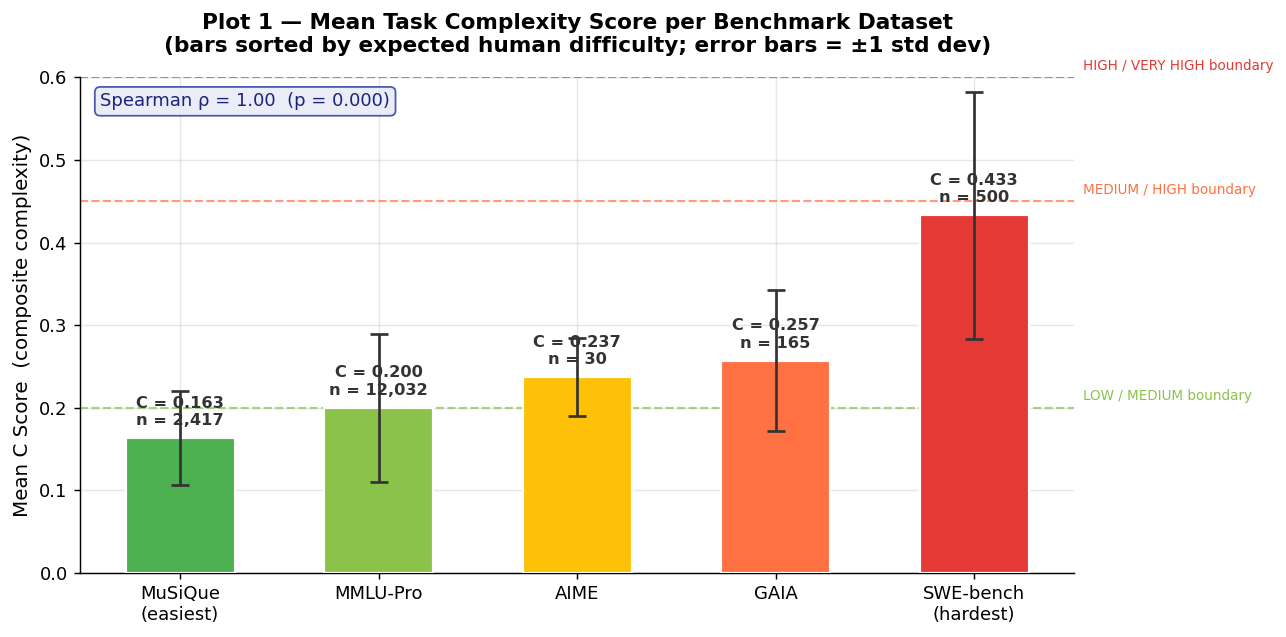

✅ Saved → plot_01_mean_complexity_per_dataset.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 — Plot 1: Mean Complexity Score per Dataset (Bar Chart)
# Story: Do our scores rank datasets in the right difficulty order?
# Expected order (easy → hard): musique < mmlu_pro < aime < gaia < swe_bench
# ─────────────────────────────────────────────────────────────────────────────

# ── Styling shared across all plots ──────────────────────────────────────────
plt.rcParams.update({
    "font.family"    : "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid"      : True,
    "grid.alpha"     : 0.3,
    "figure.dpi"     : 130,
})

# ── Data prep ─────────────────────────────────────────────────────────────────
# Use the summary_df computed in Cell 12
DISPLAY_ORDER = ["musique", "mmlu_pro", "aime", "gaia", "swe_bench"]
DISPLAY_LABELS = ["MuSiQue\n(easiest)", "MMLU-Pro", "AIME", "GAIA", "SWE-bench\n(hardest)"]
COLORS_ORDER   = ["#4caf50", "#8bc34a", "#ffc107", "#ff7043", "#e53935"]

mean_c = [summary_df.loc[d, "mean_C"] for d in DISPLAY_ORDER]
err_c  = [scored_datasets[d]["C"].std() for d in DISPLAY_ORDER]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(DISPLAY_LABELS, mean_c, color=COLORS_ORDER,
              edgecolor="white", linewidth=1.2, width=0.55, zorder=3)
ax.errorbar(range(len(DISPLAY_ORDER)), mean_c, yerr=err_c,
            fmt='none', color='#333', capsize=5, capthick=1.5,
            elinewidth=1.5, zorder=4)

# Annotate each bar with its value and n
for i, (bar, val, ds) in enumerate(zip(bars, mean_c, DISPLAY_ORDER)):
    n = len(scored_datasets[ds])
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.012,
            f"C = {val:.3f}\nn = {n:,}",
            ha='center', va='bottom', fontsize=9, color='#333', fontweight='bold')

# Band threshold lines
for thresh, label, color in [
    (0.20, "LOW / MEDIUM boundary",    "#8bc34a"),
    (0.45, "MEDIUM / HIGH boundary",   "#ff7043"),
    (0.60, "HIGH / VERY HIGH boundary","#e53935"),
]:
    ax.axhline(thresh, color=color, linewidth=1.2, linestyle='--', alpha=0.7)
    ax.text(4.55, thresh + 0.005, label, fontsize=7.5, color=color, va='bottom')

ax.set_ylim(0, 0.60)
ax.set_ylabel("Mean C Score  (composite complexity)", fontsize=11)
ax.set_title("Plot 1 — Mean Task Complexity Score per Benchmark Dataset\n"
             "(bars sorted by expected human difficulty; error bars = ±1 std dev)",
             fontsize=12, fontweight='bold', pad=14)

# Spearman annotation
rho_text = f"Spearman ρ = {rho_cross:.2f}  (p = {pval_cross:.3f})"
ax.text(0.02, 0.97, rho_text, transform=ax.transAxes,
        fontsize=10, va='top', color='#1a237e',
        bbox=dict(boxstyle='round,pad=0.3', fc='#e8eaf6', ec='#3949ab', alpha=0.9))

plt.tight_layout()
plt.savefig("plot_01_mean_complexity_per_dataset.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → plot_01_mean_complexity_per_dataset.png")

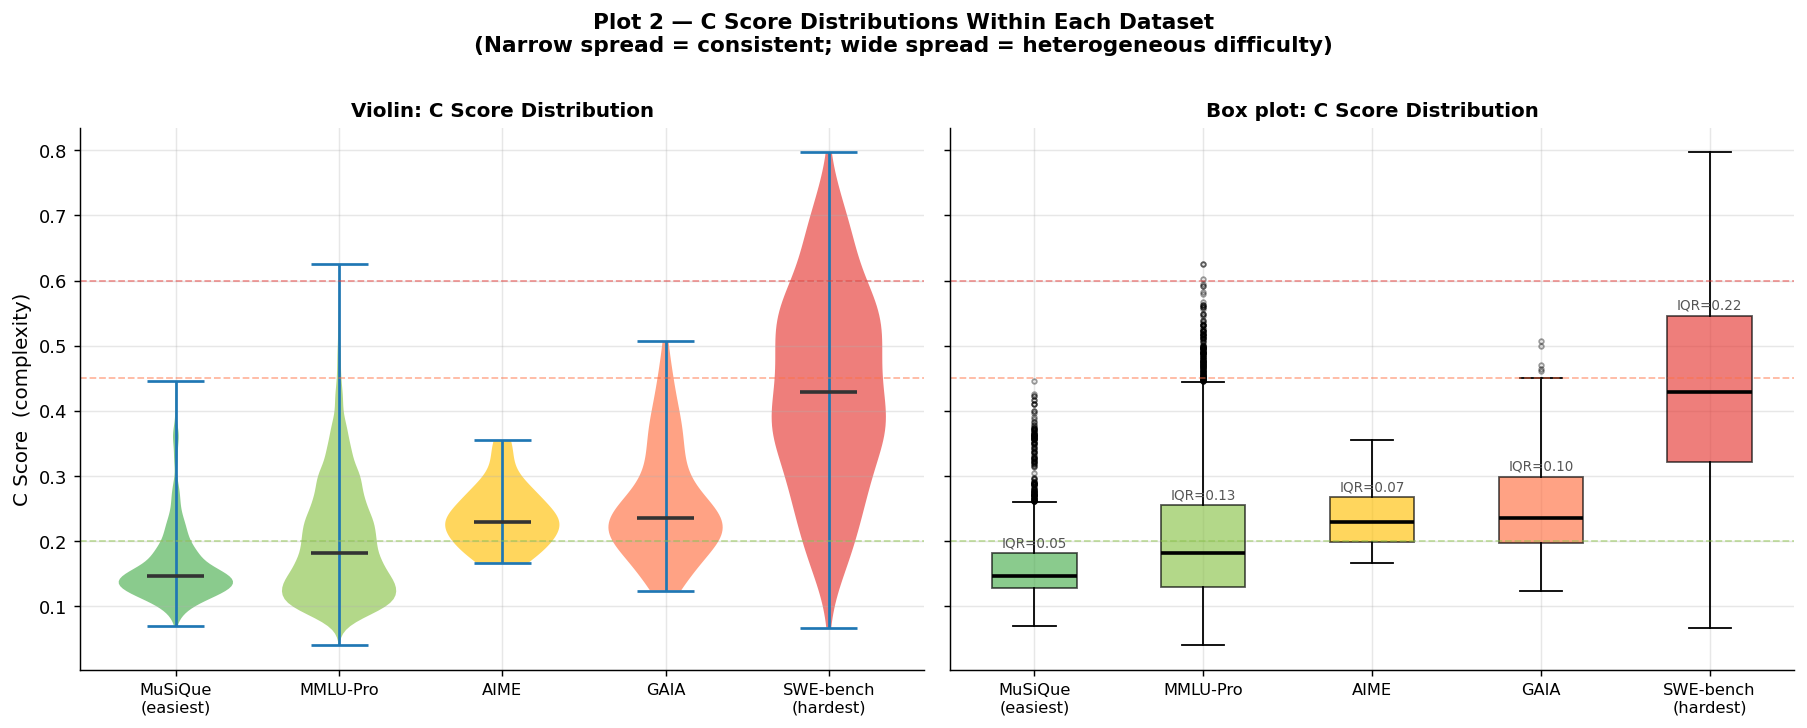

✅ Saved → plot_02_c_score_distributions.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 — Plot 2: C Score Distributions — Box + Violin per Dataset
# Story: Some datasets have wide spread (SWE-bench), others are very tight (AIME).
# A tight distribution means the scorer is consistent within that benchmark.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

plot_data = [scored_datasets[d]["C"].values for d in DISPLAY_ORDER]

# ── Left: Violin plot ────────────────────────────────────────────────────────
ax = axes[0]
parts = ax.violinplot(plot_data, positions=range(len(DISPLAY_ORDER)),
                      showmedians=True, showextrema=True, widths=0.7)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(COLORS_ORDER[i])
    pc.set_alpha(0.65)
parts['cmedians'].set_color('#333')
parts['cmedians'].set_linewidth(2)

ax.set_xticks(range(len(DISPLAY_ORDER)))
ax.set_xticklabels(DISPLAY_LABELS, fontsize=9)
ax.set_ylabel("C Score  (complexity)", fontsize=11)
ax.set_title("Violin: C Score Distribution", fontsize=11, fontweight='bold')

for thresh, col in [(0.20,'#8bc34a'),(0.45,'#ff7043'),(0.60,'#e53935')]:
    ax.axhline(thresh, color=col, linewidth=1, linestyle='--', alpha=0.5)

# ── Right: Box plot ──────────────────────────────────────────────────────────
ax2 = axes[1]
bp = ax2.boxplot(plot_data, positions=range(len(DISPLAY_ORDER)),
                 patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=2.5, alpha=0.4))
for patch, color in zip(bp['boxes'], COLORS_ORDER):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)

ax2.set_xticks(range(len(DISPLAY_ORDER)))
ax2.set_xticklabels(DISPLAY_LABELS, fontsize=9)
ax2.set_title("Box plot: C Score Distribution", fontsize=11, fontweight='bold')

for thresh, col in [(0.20,'#8bc34a'),(0.45,'#ff7043'),(0.60,'#e53935')]:
    ax2.axhline(thresh, color=col, linewidth=1, linestyle='--', alpha=0.5)

# Annotate IQR for each dataset
for i, d in enumerate(DISPLAY_ORDER):
    vals = scored_datasets[d]["C"]
    q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
    ax2.text(i, q3 + 0.01, f"IQR={q3-q1:.2f}",
             ha='center', fontsize=7.5, color='#555')

fig.suptitle("Plot 2 — C Score Distributions Within Each Dataset\n"
             "(Narrow spread = consistent; wide spread = heterogeneous difficulty)",
             fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig("plot_02_c_score_distributions.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → plot_02_c_score_distributions.png")

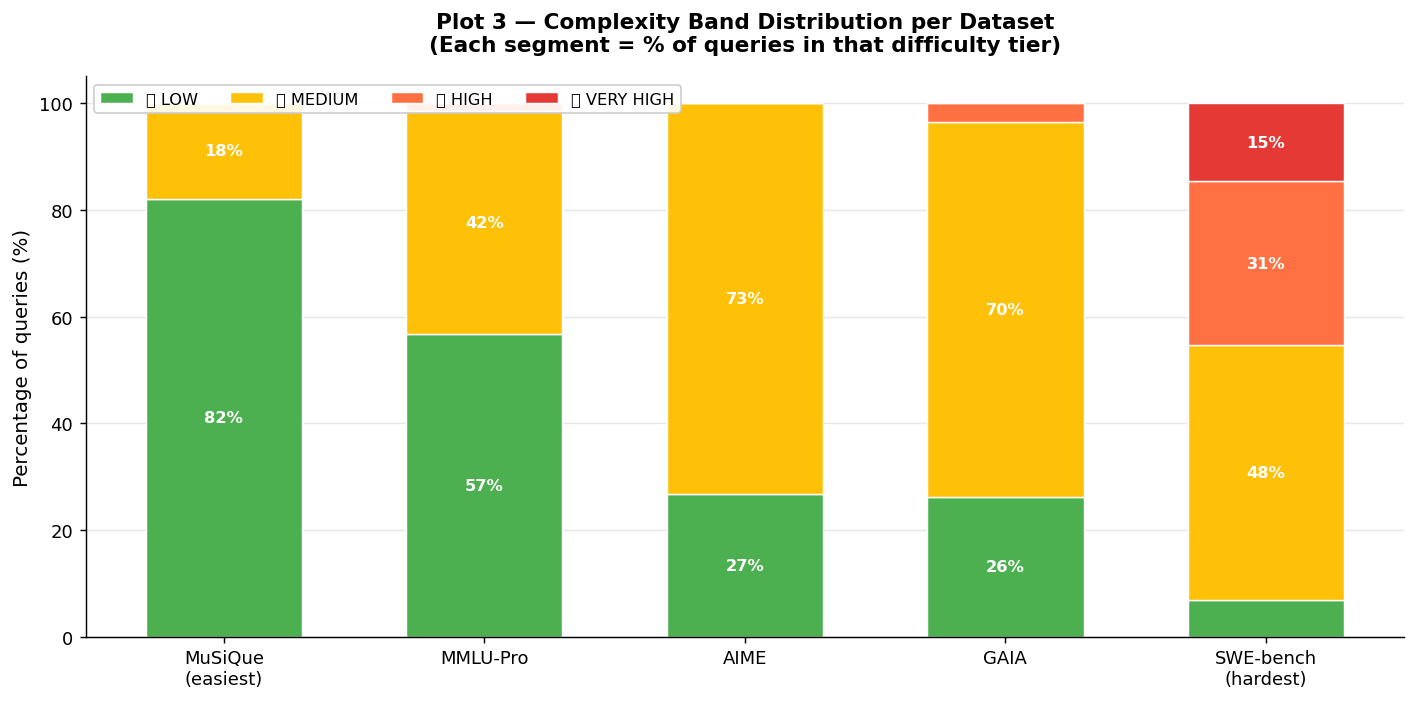

✅ Saved → plot_03_band_distribution_stacked.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 — Plot 3: Complexity Band Stacked Bar Chart
# Story: What fraction of each dataset falls into each complexity tier?
# SWE-bench should have the most VERY HIGH; MuSiQue should be mostly LOW.
# ─────────────────────────────────────────────────────────────────────────────

band_cols  = ["pct_LOW", "pct_MEDIUM", "pct_HIGH", "pct_VHIGH"]
band_names = ["🟢 LOW", "🟡 MEDIUM", "🟠 HIGH", "🔴 VERY HIGH"]
band_colors= ["#4caf50", "#ffc107", "#ff7043", "#e53935"]

fig, ax = plt.subplots(figsize=(11, 5.5))

bottom = np.zeros(len(DISPLAY_ORDER))
x = np.arange(len(DISPLAY_ORDER))

for col, name, color in zip(band_cols, band_names, band_colors):
    vals = [summary_df.loc[d, col] for d in DISPLAY_ORDER]
    bars = ax.bar(x, vals, bottom=bottom, label=name,
                  color=color, edgecolor='white', linewidth=0.8, width=0.6)
    # Label inside the segment if large enough
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 7:
            ax.text(i, b + v/2, f"{v:.0f}%",
                    ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom += np.array(vals)

ax.set_xticks(x)
ax.set_xticklabels(DISPLAY_LABELS, fontsize=10)
ax.set_ylabel("Percentage of queries (%)", fontsize=11)
ax.set_ylim(0, 105)
ax.set_title("Plot 3 — Complexity Band Distribution per Dataset\n"
             "(Each segment = % of queries in that difficulty tier)",
             fontsize=12, fontweight='bold', pad=14)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9, ncol=4)
ax.grid(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_03_band_distribution_stacked.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → plot_03_band_distribution_stacked.png")

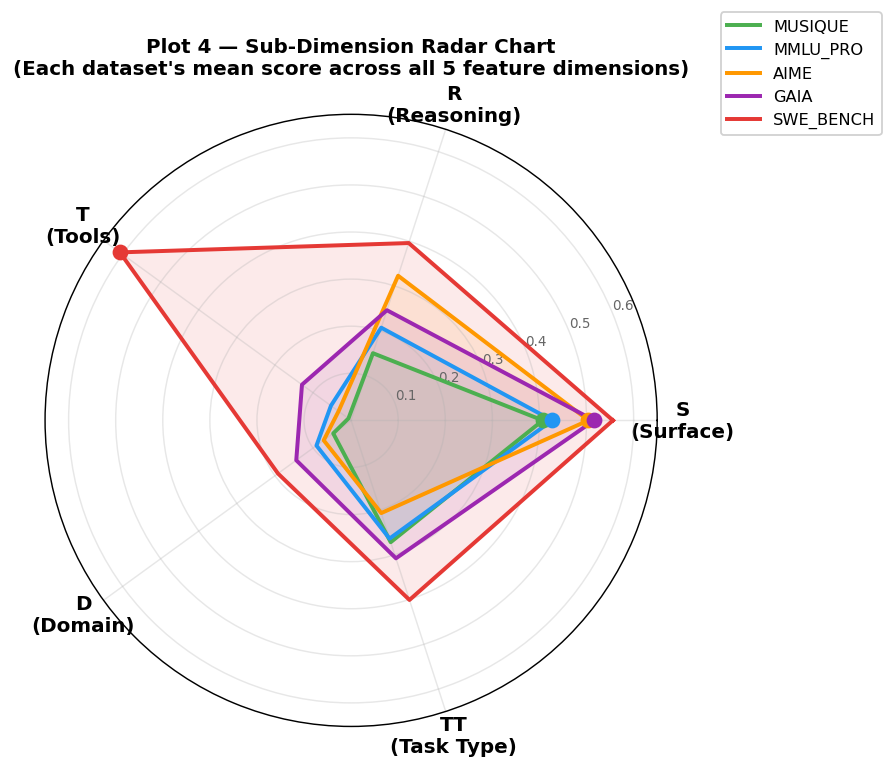

✅ Saved → plot_04_radar_subdimension_profile.png

Reading the radar chart:
  SWE-bench spikes on T (Tools) — code execution dominates
  AIME spikes on R (Reasoning) — deep mathematical cognition
  MuSiQue is small on all dims — short, simple queries
  GAIA is the most balanced — general real-world tasks


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 — Plot 4: Radar / Spider Chart — Sub-Dimension Profile per Dataset
# Story: Each dataset has a unique "fingerprint" across S, R, T, D, TT.
# SWE-bench spikes on T (Tool); AIME spikes on R (Reasoning); GAIA is balanced.
# ─────────────────────────────────────────────────────────────────────────────

from matplotlib.patches import FancyBboxPatch

dims        = ["S", "R", "T", "D", "TT"]
dim_labels  = ["S\n(Surface)", "R\n(Reasoning)", "T\n(Tools)",
               "D\n(Domain)", "TT\n(Task Type)"]
N           = len(dims)
angles      = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles     += angles[:1]  # close the polygon

radar_colors = {
    "musique"   : "#4caf50",
    "mmlu_pro"  : "#2196f3",
    "aime"      : "#ff9800",
    "gaia"      : "#9c27b0",
    "swe_bench" : "#e53935",
}

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Draw gridlines
ax.set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
ax.set_yticklabels(["0.1","0.2","0.3","0.4","0.5","0.6"], fontsize=7.5, color='#666')
ax.set_ylim(0, 0.65)

for ds, color in radar_colors.items():
    vals = [summary_df.loc[ds, f"mean_{d}"] for d in dims]
    vals += vals[:1]   # close the polygon
    ax.plot(angles, vals, color=color, linewidth=2.2, label=ds.upper())
    ax.fill(angles, vals, color=color, alpha=0.10)
    # Mark the peak dimension with a dot
    peak_idx = np.argmax(vals[:-1])
    ax.scatter(angles[peak_idx], vals[peak_idx], color=color, s=60, zorder=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dim_labels, fontsize=11, fontweight='bold')
ax.set_title("Plot 4 — Sub-Dimension Radar Chart\n"
             "(Each dataset's mean score across all 5 feature dimensions)",
             fontsize=11, fontweight='bold', pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.18), fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig("plot_04_radar_subdimension_profile.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → plot_04_radar_subdimension_profile.png")
print()
print("Reading the radar chart:")
print("  SWE-bench spikes on T (Tools) — code execution dominates")
print("  AIME spikes on R (Reasoning) — deep mathematical cognition")
print("  MuSiQue is small on all dims — short, simple queries")
print("  GAIA is the most balanced — general real-world tasks")

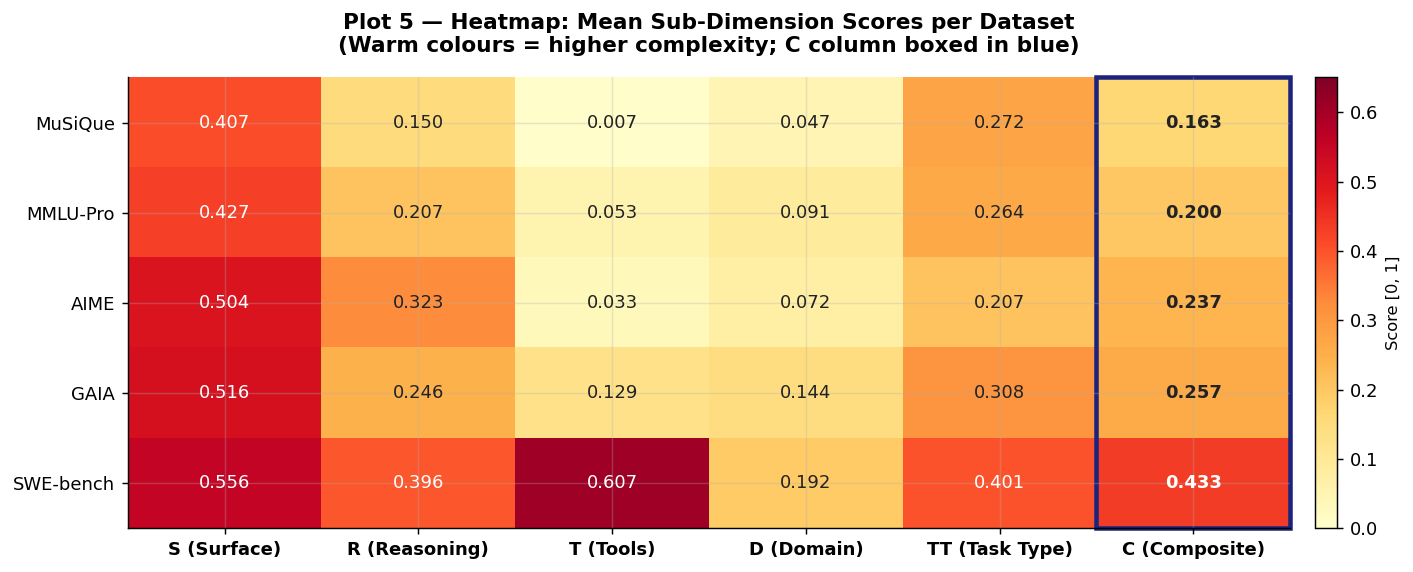

✅ Saved → plot_05_heatmap_subdimensions.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 18 — Plot 5: Heatmap of Mean Sub-Scores per Dataset
# Story: A colour table that shows at a glance which dimension drives
#        complexity in each dataset.  Warm = high, cool = low.
# ─────────────────────────────────────────────────────────────────────────────

sub_cols  = ["mean_S", "mean_R", "mean_T", "mean_D", "mean_TT", "mean_C"]
sub_labels= ["S (Surface)", "R (Reasoning)", "T (Tools)",
              "D (Domain)", "TT (Task Type)", "C (Composite)"]
row_labels = ["MuSiQue", "MMLU-Pro", "AIME", "GAIA", "SWE-bench"]

heatmap_data = np.array([
    [summary_df.loc[d, c] for c in sub_cols]
    for d in DISPLAY_ORDER
])

fig, ax = plt.subplots(figsize=(11, 4.5))

im = ax.imshow(heatmap_data, cmap="YlOrRd", aspect='auto', vmin=0, vmax=0.65)

ax.set_xticks(range(len(sub_labels)))
ax.set_xticklabels(sub_labels, fontsize=10, fontweight='bold')
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)

# Annotate every cell with its value
for i in range(len(DISPLAY_ORDER)):
    for j in range(len(sub_cols)):
        val   = heatmap_data[i, j]
        color = 'white' if val > 0.38 else '#222'
        weight= 'bold' if sub_labels[j].startswith('C') else 'normal'
        ax.text(j, i, f"{val:.3f}",
                ha='center', va='center', fontsize=10,
                color=color, fontweight=weight)

# Highlight the C column with a box
ax.add_patch(plt.Rectangle((4.5, -0.5), 1, 5,
             fill=False, edgecolor='#1a237e', lw=2.5, clip_on=False))

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Score [0, 1]", fontsize=9)

ax.set_title("Plot 5 — Heatmap: Mean Sub-Dimension Scores per Dataset\n"
             "(Warm colours = higher complexity; C column boxed in blue)",
             fontsize=12, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig("plot_05_heatmap_subdimensions.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → plot_05_heatmap_subdimensions.png")

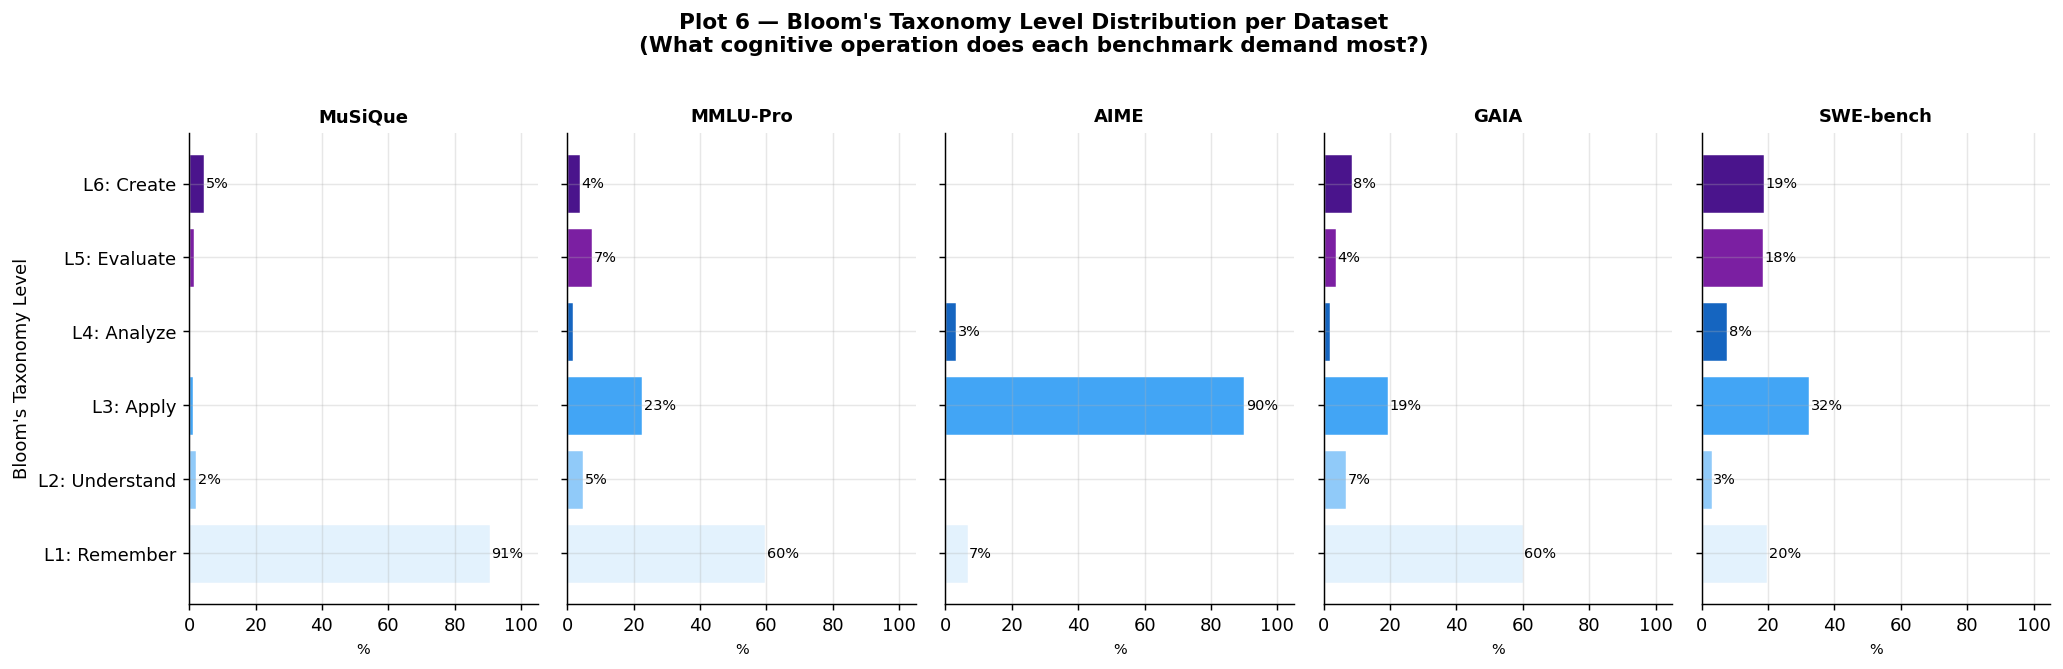

✅ Saved → plot_06_bloom_level_distribution.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 19 — Plot 6: Bloom Level Distribution per Dataset
# Story: Which cognitive level does each benchmark demand most?
# AIME & SWE-bench should have more Apply/Analyze.  MMLU-Pro should have more
# Understand/Single-answer.  MuSiQue should be mostly level 1-2.
# ─────────────────────────────────────────────────────────────────────────────

bloom_labels = {
    1: "L1: Remember",
    2: "L2: Understand",
    3: "L3: Apply",
    4: "L4: Analyze",
    5: "L5: Evaluate",
    6: "L6: Create",
}
bloom_colors = ["#e3f2fd","#90caf9","#42a5f5","#1565c0","#7b1fa2","#4a148c"]

fig, axes = plt.subplots(1, 5, figsize=(16, 5), sharey=True)

for ax, ds, label in zip(axes, DISPLAY_ORDER, row_labels):
    df_ds   = scored_datasets[ds]
    counts  = df_ds["bloom_level"].value_counts().sort_index()
    total   = len(df_ds)
    levels  = sorted(bloom_labels.keys())
    pcts    = [counts.get(lvl, 0) / total * 100 for lvl in levels]

    bars = ax.barh([bloom_labels[l] for l in levels], pcts,
                   color=bloom_colors, edgecolor='white', linewidth=0.8)
    # Annotate
    for bar, pct in zip(bars, pcts):
        if pct > 2:
            ax.text(pct + 0.5, bar.get_y() + bar.get_height()/2,
                    f"{pct:.0f}%", va='center', fontsize=8)

    ax.set_xlim(0, 105)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel("%", fontsize=8)
    ax.grid(axis='x', alpha=0.3)

axes[0].set_ylabel("Bloom's Taxonomy Level", fontsize=10)
fig.suptitle("Plot 6 — Bloom's Taxonomy Level Distribution per Dataset\n"
             "(What cognitive operation does each benchmark demand most?)",
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig("plot_06_bloom_level_distribution.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → plot_06_bloom_level_distribution.png")

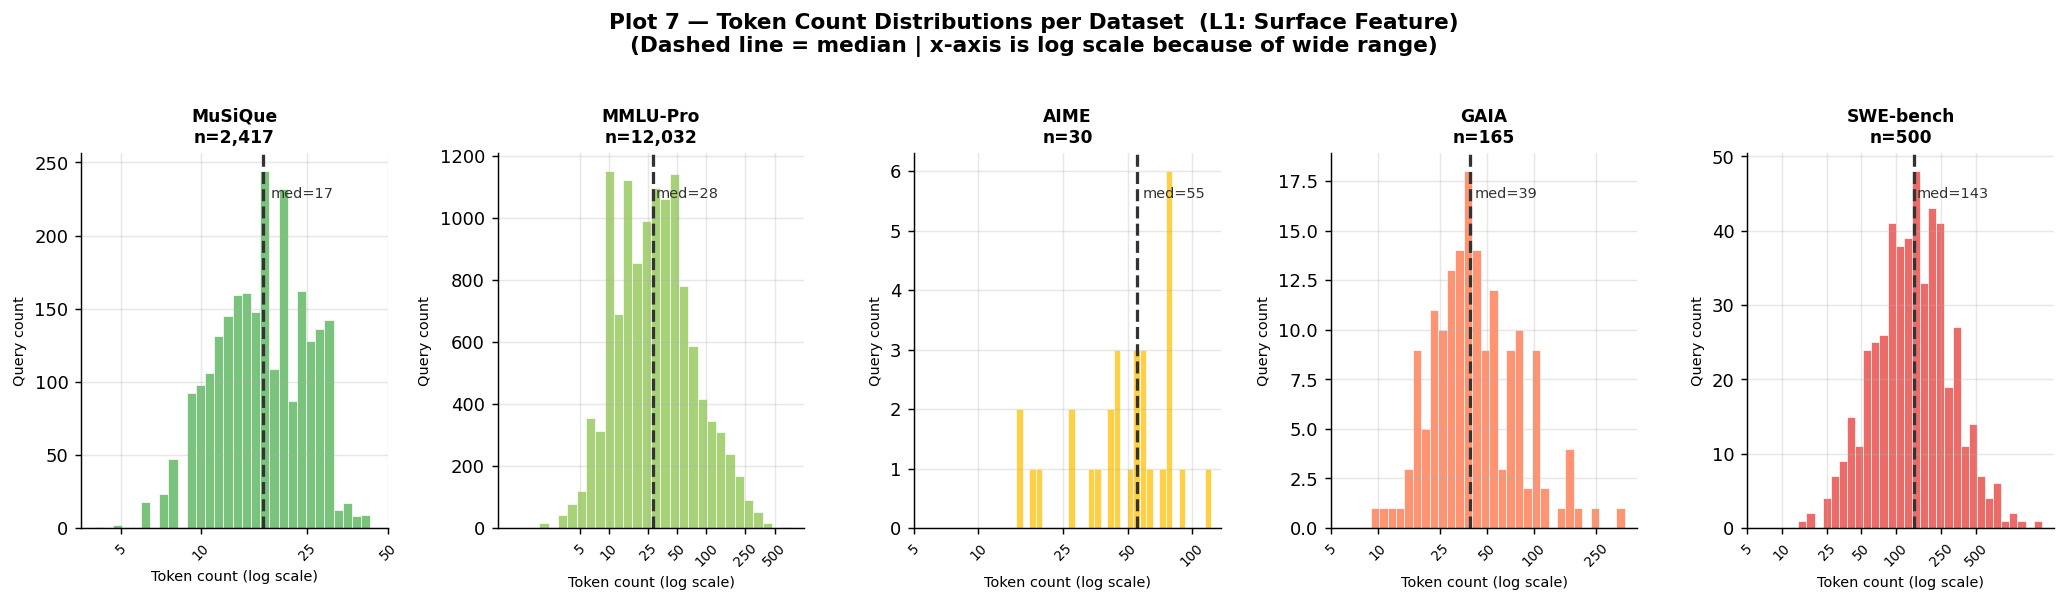

✅ Saved → plot_07_token_count_distributions.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 20 — Plot 7: Token Count Distributions (Log X-axis)
# Story: Surface feature L1 — how long are the queries in each dataset?
# SWE-bench queries are much longer (bug reports).  MuSiQue is short.
# Log x-axis used because of the wide range (5 to 2000+ tokens).
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 5, figsize=(16, 4.5), sharey=False)

for ax, ds, label, color in zip(axes, DISPLAY_ORDER, row_labels, COLORS_ORDER):
    df_ds = scored_datasets[ds]
    tc    = df_ds["query"].str.split().str.len()  # quick whitespace token count

    # KDE on log scale
    log_tc = np.log10(tc.clip(lower=1))
    ax.hist(log_tc, bins=30, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)

    # Median line
    median_log = np.log10(tc.median())
    ax.axvline(median_log, color='#333', linewidth=1.8, linestyle='--')
    ax.text(median_log + 0.03, ax.get_ylim()[1]*0.88,
            f"med={tc.median():.0f}", fontsize=8, color='#333')

    # X-axis: restore original token count labels
    tick_vals = [5, 10, 25, 50, 100, 250, 500, 2500]
    tick_vals = [v for v in tick_vals if v <= tc.max()*1.2]
    ax.set_xticks([np.log10(v) for v in tick_vals])
    ax.set_xticklabels([str(v) for v in tick_vals], fontsize=7.5, rotation=45)

    ax.set_title(f"{label}\nn={len(df_ds):,}", fontsize=9.5, fontweight='bold')
    ax.set_xlabel("Token count (log scale)", fontsize=8)
    ax.set_ylabel("Query count", fontsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle("Plot 7 — Token Count Distributions per Dataset  (L1: Surface Feature)\n"
             "(Dashed line = median | x-axis is log scale because of wide range)",
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig("plot_07_token_count_distributions.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → plot_07_token_count_distributions.png")

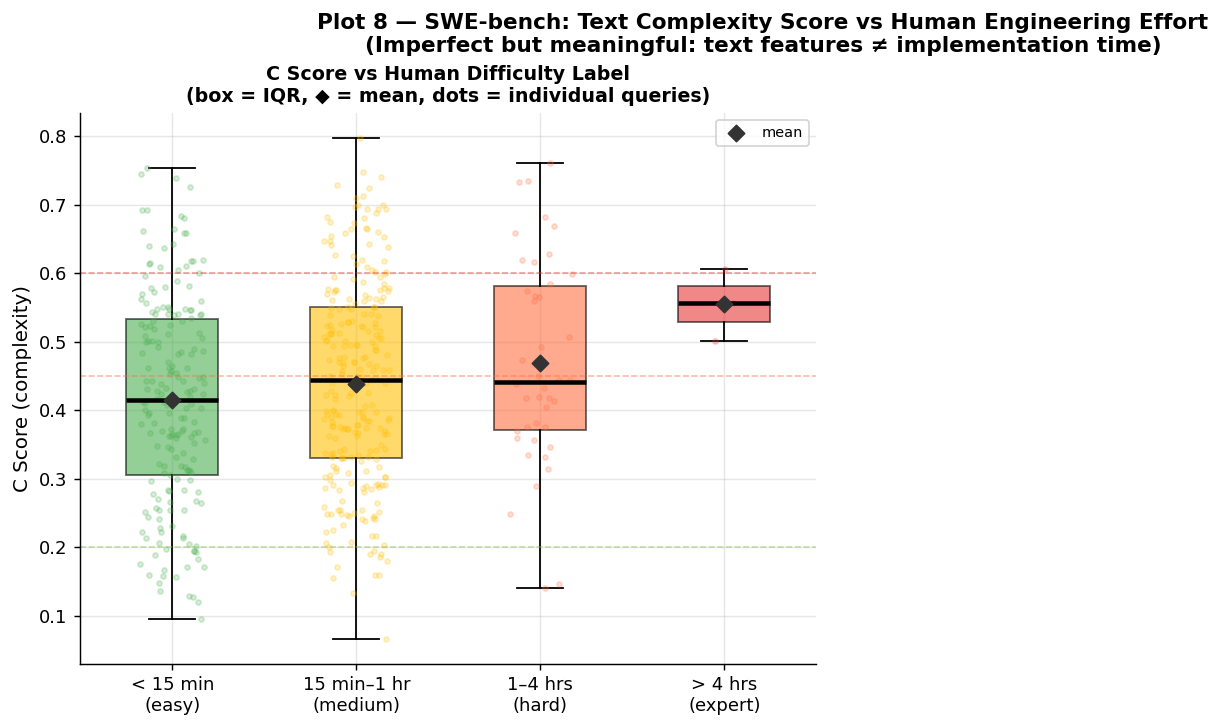

✅ Saved → plot_08_swebench_difficulty_vs_score.png

Key insight: Most queries land in MEDIUM regardless of human label.
This is because SWE-bench bugs are described in technical English — linguistically
similar regardless of coding effort. Text complexity ≠ implementation complexity.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 21 — Plot 8: SWE-bench C Score vs Human Difficulty (Box + Strip)
# Story: Do our text-based C scores align with how long engineers say tasks take?
# We expect C to increase from '<15 min' → '15min-1hr' → '1-4hr' → '>4hr'.
# The alignment is imperfect but meaningful — text ≠ code effort perfectly.
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.gridspec as gridspec

difficulty_order  = ["<15 min fix", "15 min - 1 hour", "1-4 hours", ">4 hours"]
difficulty_labels = ["< 15 min\n(easy)", "15 min–1 hr\n(medium)",
                     "1–4 hrs\n(hard)", "> 4 hrs\n(expert)"]
diff_colors       = ["#4caf50", "#ffc107", "#ff7043", "#e53935"]

swe = scored_datasets["swe_bench"].copy()
swe["difficulty"] = pd.Categorical(swe["difficulty"],
                                    categories=difficulty_order, ordered=True)
swe = swe.dropna(subset=["difficulty"])

fig = plt.figure(figsize=(14, 5.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[3, 2], wspace=0.3)

# ── Left: Box + strip plot ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

groups = [swe[swe["difficulty"] == d]["C"].values for d in difficulty_order]
bp = ax1.boxplot(groups, positions=range(len(difficulty_order)),
                 patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=2.5),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3))
for patch, color in zip(bp['boxes'], diff_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Overlay jittered individual points
rng = np.random.default_rng(42)
for i, (grp, color) in enumerate(zip(groups, diff_colors)):
    jitter = rng.uniform(-0.18, 0.18, size=len(grp))
    ax1.scatter(i + jitter, grp, alpha=0.22, s=8, color=color, zorder=2)

# Mean markers
for i, grp in enumerate(groups):
    if len(grp):
        ax1.scatter(i, grp.mean(), marker='D', s=40, color='#333',
                    zorder=5, label="mean" if i==0 else "")

ax1.set_xticks(range(len(difficulty_order)))
ax1.set_xticklabels(difficulty_labels, fontsize=10)
ax1.set_ylabel("C Score (complexity)", fontsize=11)
ax1.set_title("C Score vs Human Difficulty Label\n(box = IQR, ◆ = mean, dots = individual queries)",
              fontsize=10.5, fontweight='bold')
ax1.legend(fontsize=8)

for thresh, col in [(0.20,'#8bc34a'),(0.45,'#ff7043'),(0.60,'#e53935')]:
    ax1.axhline(thresh, color=col, linewidth=0.9, linestyle='--', alpha=0.5)



ax2.set_xticks(range(len(band_order)))
ax2.set_xticklabels(["LOW","MED","HIGH","V.HIGH"], fontsize=9, rotation=20)
ax2.set_yticks(range(len(difficulty_order)))
ax2.set_yticklabels(difficulty_labels, fontsize=9)
ax2.set_xlabel("Predicted Band", fontsize=10)
ax2.set_ylabel("Human Difficulty Label", fontsize=10)
ax2.set_title("Confusion: Human Label vs Predicted Band\n(% of row; diagonal = correct)",
              fontsize=10, fontweight='bold')
plt.colorbar(im2, ax=ax2, fraction=0.04, pad=0.04, label="% of difficulty tier")

fig.suptitle("Plot 8 — SWE-bench: Text Complexity Score vs Human Engineering Effort\n"
             "(Imperfect but meaningful: text features ≠ implementation time)",
             fontsize=12, fontweight='bold', y=1.02)

plt.savefig("plot_08_swebench_difficulty_vs_score.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved → plot_08_swebench_difficulty_vs_score.png")
print()
print("Key insight: Most queries land in MEDIUM regardless of human label.")
print("This is because SWE-bench bugs are described in technical English — linguistically")
print("similar regardless of coding effort. Text complexity ≠ implementation complexity.")